In [4]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import os, json, math, random, pickle, shutil, socket, inspect, argparse, subprocess, warnings
from collections import Counter
from transformers import AutoFeatureExtractor, ASTForAudioClassification
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

import librosa
from tqdm import tqdm
from IPython.display import Audio

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import datasets, transforms

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger

import umap
from sklearn.manifold import TSNE

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.mixture import GaussianMixture

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, GroupKFold, train_test_split
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    silhouette_score, silhouette_samples, davies_bouldin_score
)

from scipy import stats as scipy_stats
from diptest import diptest as _diptest

import train
import commons
import models
import utils
import lightning_wrapper

from cough_datasets import (
    CoughDatasets,
    CoughDatasetsCollate,
    CoughDiseaseBinaryBatchSampler
)

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

colors = {"TB": "#C0392B", "Non-TB": "#2980B9"}
bins = np.linspace(0, 1, 30)

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_801461/610647508.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [5]:
def _aprior(delta_hat: np.ndarray) -> np.ndarray:
    """ComBat EM prior: shape parameter for inverse gamma."""
    m = delta_hat.mean(axis=1)
    s2 = delta_hat.var(axis=1) + 1e-8
    return (2 * s2 + m**2) / s2

def _bprior(delta_hat: np.ndarray) -> np.ndarray:
    """ComBat EM prior: scale parameter for inverse gamma."""
    m = delta_hat.mean(axis=1)
    s2 = delta_hat.var(axis=1) + 1e-8
    return (m * s2 + m**3) / s2

def combat_harmonize(embeddings: np.ndarray,
    db_labels: np.ndarray, covariates: np.ndarray = None,
    n_iter: int = 100, conv_threshold: float = 1e-4) -> np.ndarray:
    """
    Empirical Bayes ComBat harmonization.
    
    Removes additive (gamma) and multiplicative (delta) batch effects
    while preserving biological signal via covariate design matrix.
    
    Parameters
    ----------
    embeddings   : (N, D) float array
    db_labels    : (N,) array of database IDs
    covariates   : (N, C) optional biological covariates to preserve
                   (e.g. disease_status encoded as 0/1)
    n_iter       : EM iterations for Bayesian shrinkage
    conv_threshold: convergence tolerance
    
    Returns
    -------
    harmonized   : (N, D) float array
    """
    N, D = embeddings.shape
    batches = np.unique(db_labels)
    n_batches = len(batches)
    
    # 1. Build design matrix
    # Intercept + covariates (biological signal to preserve)
    if covariates is not None:
        if covariates.ndim == 1:
            covariates = covariates.reshape(-1, 1)
        design = np.hstack([np.ones((N, 1)), covariates])
    else:
        design = np.ones((N, 1))
    
    # 2. Standardize overall
    grand_mean = embeddings.mean(axis=0)
    var_pooled = embeddings.var(axis=0) + 1e-8
    
    # 3. Regress out covariates to get residuals
    # Solve: embeddings = design @ B + residuals
    B, _, _, _ = np.linalg.lstsq(design, embeddings, rcond=None)
    residuals = embeddings - design @ B
    
    # 4. Standardize residuals
    stand_mean = (grand_mean / np.sqrt(var_pooled))
    s_data = (embeddings - grand_mean) / np.sqrt(var_pooled)
    
    # 5. Estimate batch effects (gamma_hat = additive, delta_hat = multiplicative)
    gamma_hat = np.zeros((n_batches, D))
    delta_hat = np.zeros((n_batches, D))
    
    batch_idx = {}
    for i, b in enumerate(batches):
        mask = db_labels == b
        batch_idx[i] = mask
        batch_data = s_data[mask]
        gamma_hat[i] = batch_data.mean(axis=0)
        delta_hat[i] = batch_data.var(axis=0) + 1e-8
    
    # 6. Empirical Bayes priors
    gamma_bar = gamma_hat.mean(axis=0)
    t2 = gamma_hat.var(axis=0) + 1e-8
    
    a_prior = _aprior(delta_hat)
    b_prior = _bprior(delta_hat)
    
    # 7. EM iteration for posterior estimates
    gamma_star = gamma_hat.copy()
    delta_star = delta_hat.copy()
    
    for _ in range(n_iter):
        gamma_star_new = np.zeros_like(gamma_hat)
        delta_star_new = np.zeros_like(delta_hat)
        
        for i, b in enumerate(batches):
            mask = batch_idx[i]
            n_i = mask.sum()
            batch_data = s_data[mask]
            
            # Posterior gamma (additive)
            gamma_star_new[i] = (
                (t2 * n_i * batch_data.mean(axis=0) + delta_star[i] * gamma_bar)
                / (t2 * n_i + delta_star[i])
            )
            
            # Posterior delta (multiplicative) via inverse gamma
            sum_sq = ((batch_data - gamma_star_new[i]) ** 2).sum(axis=0)
            delta_star_new[i] = (b_prior[i] + 0.5 * sum_sq) / (a_prior[i] + n_i / 2.0 - 1)
            delta_star_new[i] = np.maximum(delta_star_new[i], 1e-8)
        
        # Check convergence
        g_change = np.abs(gamma_star_new - gamma_star).max()
        d_change = np.abs(delta_star_new - delta_star).max()
        gamma_star = gamma_star_new
        delta_star = delta_star_new
        
        if g_change < conv_threshold and d_change < conv_threshold:
            break
    
    # 8. Apply correction
    harmonized = s_data.copy()
    for i, b in enumerate(batches):
        mask = batch_idx[i]
        harmonized[mask] = (
            (s_data[mask] - gamma_star[i]) / np.sqrt(delta_star[i])
        )
    
    # 9. Rescale back to original space
    harmonized = harmonized * np.sqrt(var_pooled) + grand_mean
    
    # Re-apply biological covariates
    harmonized = harmonized + design @ B - grand_mean
    
    return harmonized

def compute_mmd(X: np.ndarray, Y: np.ndarray, gamma: float = None) -> float:
    """
    Unbiased MMD² with RBF kernel.
    Lower = more similar distributions (better harmonization).
    """
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    
    def rbf_kernel(A, B):
        dists = np.sum((A[:, None] - B[None, :]) ** 2, axis=2)
        return np.exp(-gamma * dists)
    
    Kxx = rbf_kernel(X, X)
    Kyy = rbf_kernel(Y, Y)
    Kxy = rbf_kernel(X, Y)
    
    n, m = len(X), len(Y)
    mmd2 = (
        (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
        + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
        - 2 * Kxy.mean()
    )
    return float(mmd2)

def pairwise_mmd_matrix(embeddings: np.ndarray, db_labels: np.ndarray) -> pd.DataFrame:
    """Compute pairwise MMD between all database pairs."""
    batches = np.unique(db_labels)
    n = len(batches)
    matrix = np.zeros((n, n))
    
    for i, b1 in enumerate(batches):
        for j, b2 in enumerate(batches):
            if i != j:
                X = embeddings[db_labels == b1]
                Y = embeddings[db_labels == b2]
                # Subsample for speed if large
                if len(X) > 200: X = X[np.random.choice(len(X), 200, replace=False)]
                if len(Y) > 200: Y = Y[np.random.choice(len(Y), 200, replace=False)]
                matrix[i, j] = compute_mmd(X, Y)
    
    return pd.DataFrame(matrix, index=batches, columns=batches)

def get_classifiers() -> dict:
    """
    Return a dict of classifiers to compare.
    All wrapped in a Pipeline with StandardScaler + PCA for fair comparison.
    PCA(50) reduces 4096-dim embeddings to a stable space for all classifiers.
    """
    pca_step = ("pca", PCA(n_components=50, random_state=42))
    scale_step = ("scaler", StandardScaler())

    return {
        "Logistic Regression": Pipeline([
            scale_step, pca_step,
            ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
        ]),
        "Neural Network (MLP)": Pipeline([
            scale_step,
            pca_step,
            ("clf", MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=64,
                learning_rate_init=1e-3,
                max_iter=300,
                early_stopping=True,
                random_state=42
            )),
        ]),
        "SVM (RBF)": Pipeline([
            scale_step, pca_step,
            ("clf", SVC(kernel="rbf", probability=True, C=1.0, random_state=42)),
        ]),
        # "Random Forest": Pipeline([
        #     scale_step, pca_step,
        #     ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        # ]),
        # "Gradient Boosting": Pipeline([
        #     scale_step, pca_step,
        #     ("clf", GradientBoostingClassifier(n_estimators=200, random_state=42)),
        # ]),
    }

def compute_auc(y_true, y_proba):
    classes = np.unique(y_true)

    # Binary case
    if len(classes) == 2:
        # handle (n_samples,) or (n_samples, 2)
        if y_proba.ndim == 2:
            y_score = y_proba[:, 1]
        else:
            y_score = y_proba
        return roc_auc_score(y_true, y_score)

    # Multiclass case
    else:
        return roc_auc_score(
            y_true,
            y_proba,
            multi_class="ovr",
            average="macro"
        )

def run_embedding_classification(
    df,
    train_db,
    test_dbs=None,
    embed_col="embed",
    label_col="disease_status",
    participant_col="participant",
    db_col="db",
    n_splits=5,
    classifiers=None
):
    """
    Flexible evaluation pipeline for embedding-based classification.

    Parameters
    ----------
    df : DataFrame
        Combined dataframe containing embeddings and metadata.
    train_db : int or list
        DB id(s) used for training + cross-validation.
    test_dbs : list or None
        DB ids used as external evaluation sets.
    embed_col : str
        Column containing embeddings.
    label_col : str
        Label column.
    participant_col : str
        Column used for GroupKFold grouping.
    db_col : str
        Database identifier column.
    n_splits : int
        Number of CV folds.
    classifiers : dict
        Dict of sklearn classifiers.

    Returns
    -------
    results : dict
        Mean and std metrics across folds for each classifier.
    """

    if classifiers is None:
        classifiers = get_classifiers()

    if not isinstance(train_db, list):
        train_db = [train_db]

    if test_dbs is None:
        test_dbs = []

    df_train = df[df[db_col].isin(train_db)].copy()

    X = np.vstack(df_train[embed_col].values).astype(np.float32)
    y = df_train[label_col].astype(int).values
    groups = df_train[participant_col].values

    external_sets = {}
    for db in test_dbs:
        df_ext = df[df[db_col] == db]
        X_ext = np.vstack(df_ext[embed_col].values).astype(np.float32)
        y_ext = df_ext[label_col].astype(int).values
        external_sets[db] = (X_ext, y_ext)

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    splits = list(cv.split(X, y, groups=groups))

    model_results = {}
    for clf_name, clf in tqdm(classifiers.items(), desc="Training classifiers"):
        fold_aurocs = []
        fold_aurocs_ext = {db: [] for db in test_dbs}

        for train_idx, test_idx in splits:
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            clf.fit(X_train, y_train)

            y_proba = clf.predict_proba(X_test)
            fold_aurocs.append(compute_auc(y_test, y_proba))

            for db in test_dbs:
                X_ext, y_ext = external_sets[db]
                y_proba_ext = clf.predict_proba(X_ext)
                fold_aurocs_ext[db].append(compute_auc(y_ext, y_proba_ext))

        model_results[clf_name] = {
            "auroc": np.mean(fold_aurocs),
            **{
                f"auroc_db{db}": np.mean(vals)
                for db, vals in fold_aurocs_ext.items()
            }
        }
        
    # -------- aggregate across models --------
    all_aurocs = [v["auroc"] for v in model_results.values()]

    summary = {
        "all": f"{np.mean(all_aurocs):.2f} ± {np.std(all_aurocs):.2f}"
    }

    for db in test_dbs:
        vals = [v[f"auroc_db{db}"] for v in model_results.values()]
        summary[f"db_{db}"] = f"{np.mean(vals):.2f} ± {np.std(vals):.2f}"

    return summary, model_results

def _sigmoid_normalize(scores: np.ndarray) -> np.ndarray:
    """Center and sigmoid-normalize scores to [0, 1]."""
    centered = (scores - scores.mean()) / (scores.std() + 1e-8)
    return 1.0 / (1.0 + np.exp(-centered))

def _minmax_normalize(scores: np.ndarray) -> np.ndarray:
    lo, hi = scores.min(), scores.max()
    return (scores - lo) / (hi - lo + 1e-8)

def best_gmm(data, max_k=6, random_state=42):
    best_bic, best_k = np.inf, 1
    max_k = min(max_k, len(data) // 20)  # need enough samples per component
    max_k = max(max_k, 1)
    for k in tqdm(range(1, max_k + 1)):
        try:
            g = GaussianMixture(n_components=k, covariance_type="diag", random_state=random_state, n_init=3)
            g.fit(data)
            bic = g.bic(data)
            if bic < best_bic:
                best_bic, best_k = bic, k
        except Exception:
            break
    gmm = GaussianMixture(n_components=best_k, covariance_type="diag",
                            random_state=random_state, n_init=5)
    gmm.fit(data)
    print(f"    GMM components selected (BIC): {best_k}")
    return gmm

def find_optimal_k(
    embeddings: np.ndarray,
    k_range: range = None,
    random_state: int = 42,
) -> tuple[int, pd.DataFrame]:
    """
    Find optimal number of clusters via silhouette + elbow analysis.
    
    Returns
    -------
    best_k     : recommended number of clusters
    metrics_df : per-k metrics table
    """
    if k_range is None:
        k_range = range(2, min(8, len(embeddings) // 10 + 1))
    
    pca = PCA(n_components=min(50, embeddings.shape[1]), random_state=random_state)
    emb_pca = pca.fit_transform(embeddings)
    
    records = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        labels = km.fit_predict(emb_pca)
        
        sil = silhouette_score(emb_pca, labels)
        inertia = km.inertia_
        db = davies_bouldin_score(emb_pca, labels)
        records.append({"k": k, "silhouette": sil, "inertia": inertia, "davies_bouldin": db})
    
    df = pd.DataFrame(records)
    
    # Best k = highest silhouette (or use elbow)
    best_k = int(df.loc[df["silhouette"].idxmax(), "k"])
    
    return best_k, df

def gmm_acoustic_threshold(acoustic_scores, tb_mask, max_k=6, random_state=42):
    scores = np.asarray(acoustic_scores)
    scores_2d = scores.reshape(-1, 1)

    # ── BIC model selection ─────────────────────────
    bics, models = [], []
    for k in range(1, max_k + 1):
        try:
            g = GaussianMixture(
                n_components=k,
                covariance_type="full",
                n_init=10,
                random_state=random_state,
                max_iter=300
            )
            g.fit(scores_2d)
            bics.append(g.bic(scores_2d))
            models.append(g)
        except Exception:
            bics.append(np.inf)
            models.append(None)

    best_k = int(np.argmin(bics)) + 1
    best_gmm = models[best_k - 1]

    # ── fallback if only 1 component ────────────────
    if best_k == 1:
        print(f" Return to Percentile Threshold")
        return float(np.percentile(scores[~tb_mask], 95))

    # ── posterior crossover threshold ───────────────
    means = best_gmm.means_.flatten()
    order = np.argsort(means)

    comp_acoustic = int(order[-1])

    x_range = np.linspace(scores.min(), scores.max(), 10000).reshape(-1, 1)
    p_range = best_gmm.predict_proba(x_range)[:, comp_acoustic]

    cross_idx = int(np.argmin(np.abs(p_range - 0.5)))
    final_threshold = float(x_range[cross_idx, 0])

    return final_threshold

def majority_vote(group):
    counts = group["disease_status_rev"].value_counts(normalize=True)
    if counts.get(1, 0) > 0.51:
        return 1
    elif counts.get(2, 0) > 0.51:
        return 2
    else:
        return 2

def print_tb_stats(df_temp, tb_mask0):
    tb_df = df_temp[tb_mask0]

    vc = tb_df["disease_status_rev"].value_counts()
    total = len(tb_df)

    print(f"Acoustic-TB: {vc.get(1,0)} ({vc.get(1,0)/total*100:.1f}%) | "
          f"Label-only-TB: {vc.get(2,0)} ({vc.get(2,0)/total*100:.1f}%)")

    db_counts = tb_df.groupby(["db","disease_status_rev"]).size().unstack(fill_value=0)

    print("Acoustic-TB -> " + " | ".join(
        f"DB {db}: {int(db_counts.loc[db].get(1,0))} ({v:.1f}%)"
        for db, v in (db_counts.get(1, 0).div(db_counts.sum(1))*100).items()
    ) + "\n")

def revised_label_df(df_combine, acoustic_scores, global_thres=True, majority_participant=True):
    df_temp = df_combine.copy()
    df_temp["acoustic_tb_score"] = acoustic_scores

    tb_mask0 = df_temp["disease_status"] == 1
    df_temp["disease_status_rev"] = 0

    #threshold_0 = df_temp[tb_mask0]['acoustic_tb_score'].median()
    if global_thres:
        threshold_0 = gmm_acoustic_threshold(acoustic_scores, tb_mask0)
        df_temp.loc[tb_mask0, "disease_status_rev"] = np.where(
            df_temp.loc[tb_mask0, "acoustic_tb_score"].values >= threshold_0,
            1, 2
        )
    else:
        for db in df_temp["db"].unique():
            db_mask = df_temp["db"] == db
            mask = db_mask & tb_mask0

            scores_db = df_temp.loc[db_mask, "acoustic_tb_score"].values
            tb_mask_db = df_temp.loc[db_mask, "disease_status"].values == 1

            threshold_db = gmm_acoustic_threshold(scores_db, tb_mask_db)
            df_temp.loc[mask, "disease_status_rev"] = np.where(
                df_temp.loc[mask, "acoustic_tb_score"].values >= threshold_db,
                1, 2
            )

    if majority_participant:
        # Step 2: participant-level majority voting
        participant_labels = (
            df_temp.groupby("participant")
            .apply(majority_vote, include_groups=False)
            .rename("participant_label")
        )

        df_temp = df_temp.merge(
            participant_labels, left_on="participant", right_index=True, how="left"
        )
        
    print_tb_stats(df_temp, tb_mask0)
    return df_temp

def evaluate_acoustic_tb(df_combine, acoustic_scores, global_thres=True):
    df_temp = revised_label_df(df_combine, acoustic_scores, global_thres=global_thres)

    df_temp_eval = (
        df_temp[
            (df_temp["disease_status_rev"] != 2) & (df_temp["db"] != 3)
        ]
        .copy()
        .reset_index(drop=True)
    )

    summary, model_results = run_embedding_classification(
        df_temp_eval,
        train_db=0,
        test_dbs=[1, 2],
        label_col="disease_status_rev",
    )

    print(summary)
    return df_temp

def _auto_pca_components(
    embeddings: np.ndarray,
    variance_threshold: float = 0.95,
    random_state: int = 42,
) -> int:
    """
    Find minimum n_components that explains `variance_threshold` of total variance.
    Fits PCA with full components, reads cumulative explained variance ratio.

    Parameters
    ----------
    variance_threshold : float in (0, 1]
        Target cumulative explained variance. Default 0.95 (95%).
        Use 0.99 for higher fidelity, 0.90 for more compression.

    Returns
    -------
    n_components : int — minimum dims to reach the threshold
    explained    : float — actual variance explained at that n
    """
    max_comp = min(embeddings.shape[0] - 1, embeddings.shape[1])
    pca_full = PCA(n_components=max_comp, random_state=random_state)
    pca_full.fit(embeddings)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = int(np.searchsorted(cumvar, variance_threshold) + 1)
    n_comp = min(n_comp, max_comp)
    explained = cumvar[n_comp - 1]
    print(f"      Auto PCA: {n_comp} components explain {explained*100:.1f}% variance "
          f"(threshold={variance_threshold*100:.0f}%)")
    return n_comp, explained

def _posterior(log_p_tb, log_p_nontb):
    """Numerically stable Bayesian posterior P(TB|x) from log-likelihoods."""
    log_max = np.maximum(log_p_tb, log_p_nontb)
    num = np.exp(log_p_tb - log_max)
    den = num + np.exp(log_p_nontb - log_max) + 1e-8
    return (num / den).astype(np.float32)

def clip_scores(scores, tb_mask=None, min_samples=50):
    scores = np.asarray(scores)
    scores_clipped = scores.copy()

    # --- Global fallback ---
    if tb_mask is None:
        Q1 = np.percentile(scores, 25)
        Q3 = np.percentile(scores, 75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        return np.clip(scores, lower, upper)

    # --- Ensure boolean mask ---
    tb_mask = np.asarray(tb_mask).astype(bool)
    ntb_mask = ~tb_mask

    # --- TB group ---
    tb_scores = scores[tb_mask]
    if len(tb_scores) >= min_samples:
        Q1_tb = np.percentile(tb_scores, 25)
        Q3_tb = np.percentile(tb_scores, 75)
        IQR_tb = Q3_tb - Q1_tb

        lower_tb = Q1_tb - 1.5 * IQR_tb
        upper_tb = Q3_tb + 1.5 * IQR_tb

        scores_clipped[tb_mask] = np.clip(tb_scores, lower_tb, upper_tb)

    # --- Non-TB group ---
    ntb_scores = scores[ntb_mask]
    if len(ntb_scores) >= min_samples:
        Q1_ntb = np.percentile(ntb_scores, 25)
        Q3_ntb = np.percentile(ntb_scores, 75)
        IQR_ntb = Q3_ntb - Q1_ntb

        lower_ntb = Q1_ntb - 1.5 * IQR_ntb
        upper_ntb = Q3_ntb + 1.5 * IQR_ntb

        scores_clipped[ntb_mask] = np.clip(ntb_scores, lower_ntb, upper_ntb)

    return scores_clipped

def knn_tb_score(emb_reduced, tb_mask, automate_k=False, k_tb=15, k_nontb=15, alpha=20, metric="euclidean"):
    tb_emb   = emb_reduced[tb_mask]
    nontb_emb = emb_reduced[~tb_mask]

    kw_nn = {"metric": metric}
    if metric == "mahalanobis":
        cov = np.cov(emb_reduced.T)
        VI = np.linalg.inv(cov + np.eye(cov.shape[0]) * 1e-6)
        kw_nn["metric_params"] = {"VI": VI}

    if automate_k:
        k_tb, _ = find_optimal_k(tb_emb, random_state=42)
        k_nontb, _ = find_optimal_k(nontb_emb, random_state=42)

    print(f"k_tb: {k_tb} | k_nontb: {k_nontb}")

    # Fit separate NN indices for each class
    nn_tb = NearestNeighbors(n_neighbors=k_tb, n_jobs=-1, **kw_nn).fit(tb_emb)
    nn_nontb = NearestNeighbors(n_neighbors=k_nontb, n_jobs=-1, **kw_nn).fit(nontb_emb)

    # Query distances for all samples
    d_tb, _ = nn_tb.kneighbors(emb_reduced)
    d_nontb, _ = nn_nontb.kneighbors(emb_reduced)

    mean_d_tb = d_tb.mean(axis=1)
    mean_d_nontb = d_nontb.mean(axis=1)

    #mean_d_tb = clip_scores(mean_d_tb)
    #mean_d_nontb = clip_scores(mean_d_nontb)

    # Total Distance Score, [nonTB] ----------- x --- [TB] -> 0 - 1, tell how far from non tb
    # scores_raw = mean_d_nontb / (mean_d_tb + mean_d_nontb + 1e-8) # Relative proximity score: high = closer to TB
    margin = mean_d_nontb - mean_d_tb
    margin[tb_mask] = clip_scores(margin[tb_mask])
    margin[~tb_mask] = clip_scores(margin[~tb_mask])
    scores_raw = 1 / (1 + np.exp(-alpha * margin))  
    return _minmax_normalize(scores_raw)

def validate_acoustic_score_indiv(embeddings, disease_labels, acoustic_scores, k_neighbours: int = 15, random_state: int = 42) -> dict:
    """
    Four principled tests that the acoustic_tb_score reflects a real
    acoustic TB signal rather than an arbitrary or coincidental ranking.

    All tests are label-agnostic in spirit — they do not use AUROC
    against TB/NonTB labels as a criterion, avoiding the circularity
    of evaluating a score built from those same labels.

    Tests
    ─────
    1. Bimodality (Hartigan's Dip Test)
       Tests whether the TB score distribution is bimodal — a necessary
       condition if Acoustic-TB and Label-only-TB are real subgroups.
       A unimodal distribution means the threshold is arbitrary.
       → p < 0.05 on TB scores supports the existence of two subgroups.

    5. Neighbourhood Purity
       In the embedding space: what fraction of each Acoustic-TB sample's
       k nearest neighbours are also Acoustic-TB vs Label-only-TB vs NonTB?
       If the score-derived labels are real, Acoustic-TB samples should
       cluster with each other more than with Label-only-TB or NonTB.
       This tests geometric consistency — a necessary condition for reality.
       → Acoustic-TB purity >> Label-only-TB purity = geometrically consistent.

    6. Permutation Test
       Randomly shuffle TB/NonTB labels 1000 times, recompute score
       separation (TB mean - NonTB mean) each time.
       If real label structure produces separation unlikely under random
       labelling, the score is detecting something real about TB labels.
       → p < 0.05 = real separation unlikely by chance.

    Returns
    -------
    dict with per-test results, overall verdict, and saved plots.
    """

    tb_mask = disease_labels == 1
    tb_scores = acoustic_scores[tb_mask]
    nt_scores = acoustic_scores[~tb_mask]
    results   = {}

    # ── Test 1: Bimodality (Hartigan's Dip Test) ──────────────
    dip_stat, dip_pval = _diptest(tb_scores)
    bimodal = dip_pval < 0.05
    results["bimodality"] = {
        "dip_stat":  float(dip_stat),
        "dip_pval":  float(dip_pval),
        "bimodal":   bimodal,
        "n_tb":      int(tb_mask.sum()),
    }
    sig = "***" if dip_pval < 0.001 else "**" if dip_pval < 0.01 else "*" if dip_pval < 0.05 else "n.s."
    verdict1 = "✓ BIMODAL — two subgroups supported" if bimodal else "✗ UNIMODAL — threshold may be arbitrary"
    #print(f"  Dip statistic: {dip_stat:.4f}  p={dip_pval:.4f} {sig}")
    print(f"  → {verdict1}")

    # ── Test 5: Neighbourhood Purity ──────────────────────────
    # Reconstruct subtype labels using threshold from acoustic scores
    # Use 95th pct of NonTB as threshold (same as classify_tb_subgroups)
    threshold = np.percentile(nt_scores, 95)
    subtype = np.array(["Non-TB"] * len(embeddings), dtype=object)
    tb_idx  = np.where(tb_mask)[0]
    for i, idx in enumerate(tb_idx):
        subtype[idx] = "Acoustic-TB" if tb_scores[i] >= threshold else "Label-only-TB"

    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k_neighbours + 1, metric="euclidean", n_jobs=-1)
    nn.fit(embeddings)
    _, indices = nn.kneighbors(embeddings)
    indices    = indices[:, 1:]   # exclude self

    purity = {}
    for target_type in ["Acoustic-TB", "Label-only-TB"]:
        target_idx = np.where(subtype == target_type)[0]
        if len(target_idx) == 0:
            continue

        same_frac, atb_frac, lonly_frac, ntb_frac = [], [], [], []
        for idx in target_idx:
            nbr_subtypes = subtype[indices[idx]]
            same_frac.append((nbr_subtypes == target_type).mean())
            atb_frac.append((nbr_subtypes == "Acoustic-TB").mean())
            lonly_frac.append((nbr_subtypes == "Label-only-TB").mean())
            ntb_frac.append((nbr_subtypes == "Non-TB").mean())

        purity[target_type] = {
            "n":            len(target_idx),
            "same_purity":  float(np.mean(same_frac)),
            "atb_frac":     float(np.mean(atb_frac)),
            "labelonly_frac": float(np.mean(lonly_frac)),
            "nontb_frac":   float(np.mean(ntb_frac)),
        }

        # print(f"  {target_type} (n={len(target_idx)}):")
        # print(f"    Neighbours that are same subtype : {np.mean(same_frac)*100:.1f}%")
        # print(f"    Neighbours that are Acoustic-TB  : {np.mean(atb_frac)*100:.1f}%")
        # print(f"    Neighbours that are Label-only-TB: {np.mean(lonly_frac)*100:.1f}%")
        # print(f"    Neighbours that are Non-TB       : {np.mean(ntb_frac)*100:.1f}%")

    results["neighbourhood_purity"] = purity

    # Purity verdict: Acoustic-TB should have higher same-type purity than Label-only-TB
    atb_purity   = purity.get("Acoustic-TB",    {}).get("same_purity", 0)
    lonly_purity = purity.get("Label-only-TB",  {}).get("same_purity", 0)
    lonly_nontb  = purity.get("Label-only-TB",  {}).get("nontb_frac", 0)
    consistent_purity = (atb_purity > lonly_purity) and (lonly_nontb > 0.2)
    verdict5 = (
        f"✓ GEOMETRICALLY CONSISTENT — Acoustic-TB clusters with itself "
        f"({atb_purity*100:.1f}%), Label-only-TB mixes with Non-TB ({lonly_nontb*100:.1f}%)"
        if consistent_purity else
        f"✗ NOT CONSISTENT — subtypes don't separate geometrically "
        f"(Acoustic-TB purity={atb_purity*100:.1f}%)"
    )
    print(f"  → {verdict5}")

    # ── Overall verdict ────────────────────────────────────────
    n_pass = sum([
        bimodal,
        consistent_purity,
    ])
    overall = (
        "✓ SCORE IS MEANINGFUL" if n_pass >= 2 else
        "⚠ SCORE IS PARTIALLY SUPPORTED" if n_pass == 1 else
        "✗ SCORE MAY NOT BE MEANINGFUL"
    )
    results["n_tests_passed"] = n_pass
    results["overall_verdict"] = overall

    # print("\n" + "─" * 60)
    # print(f"  Tests passed: {n_pass}/3")
    # print(f"  {overall}")
    # print("─" * 60)

    return results

def plot_tb_score_distributions(df_temp, bins, colors, figsize=(20, 10)):
    """
    Plot histogram + boxplot comparison of TB likelihood scores.

    Parameters
    ----------
    score_key : str
        Key to select which score to visualize (e.g., "knn_euc").
    bins : int or sequence
        Histogram bins.
    colors : dict
        Color mapping, e.g. {"TB": "...", "Non-TB": "..."}.
    masks : list of tuple
        [(mask_tb, label_tb, label_non_tb), ...]
    titles : list[str], optional
        Column titles.
    figsize : tuple
        Figure size.
    """
    
    sel_scores = df_temp['acoustic_tb_score'].values
    n_cols = len(df_temp['db'].unique()) + 1

    fig, axes = plt.subplots(2, n_cols, figsize=figsize)
    for i, (idx_db) in enumerate(range(n_cols)):
        idx_db = idx_db - 1
        if idx_db == -1:
            tb_mask = df_temp['disease_status'] == 1
            ntb_mask = df_temp['disease_status'] == 0
        else:
            tb_mask = (df_temp['disease_status'] == 1) & (df_temp['db'] == idx_db)
            ntb_mask = (df_temp['disease_status'] == 0) & (df_temp['db'] == idx_db)

        non_tb_scores = sel_scores[ntb_mask]
        tb_scores = sel_scores[tb_mask]
        dise_label = df_temp[ntb_mask | tb_mask]['disease_status'].values

        auc = roc_auc_score(dise_label, sel_scores[ntb_mask | tb_mask]) 
        non_tb_label, tb_label = (f"Non-TB DB{idx_db}", f"TB DB{idx_db}")

        # Histogram
        ax = axes[0, i]
        ax.hist(
            non_tb_scores,
            bins=bins,
            color=colors["Non-TB"],
            alpha=0.65,
            label=f"{non_tb_label} (μ={non_tb_scores.mean():.2f})",
            density=True
        )
        ax.hist(
            tb_scores,
            bins=bins,
            color=colors["TB"],
            alpha=0.65,
            label=f"{tb_label} (μ={tb_scores.mean():.2f})",
            density=True
        )

        ax.set_xlabel("Acoustic TB Likelihood Score")
        ax.set_ylabel("Density")
        ax.legend()
        ax.set_title(f"All TB vs Non-TB DB{idx_db} {auc:0.3f}")

        # Boxplot
        ax = axes[1, i]
        data_plot = [non_tb_scores, tb_scores]

        bp = ax.boxplot(
            data_plot,
            patch_artist=True,
            widths=0.5,
            medianprops=dict(color="white", linewidth=2)
        )

        for patch, color in zip(bp["boxes"], [colors["Non-TB"], colors["TB"]]):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)

        ax.set_xticks([1, 2])
        ax.set_xticklabels([non_tb_label, tb_label], fontsize=10)
        ax.set_ylabel("Score", fontsize=9)

    plt.tight_layout()
    plt.show()

def plot_tb_split_filter(df_temp, bins, figsize=(16, 5)):
    """
    Plot histogram + boxplot comparison of TB likelihood scores.

    Parameters
    ----------
    score_key : str
        Key to select which score to visualize (e.g., "knn_euc").
    bins : int or sequence
        Histogram bins.
    colors : dict
        Color mapping, e.g. {"TB": "...", "Non-TB": "..."}.
    masks : list of tuple
        [(mask_tb, label_tb, label_non_tb), ...]
    titles : list[str], optional
        Column titles.
    figsize : tuple
        Figure size.
    """
    
    sel_scores = df_temp['acoustic_tb_score'].values
    n_cols = len(df_temp['db'].unique()) + 1

    fig, axes = plt.subplots(1, n_cols, figsize=figsize)
    for i, (idx_db) in enumerate(range(n_cols)):
        idx_db = idx_db - 1
        if idx_db == -1:
            tb_mask = df_temp['disease_status'] == 1
            ntb_mask = df_temp['disease_status'] == 0
        else:
            tb_mask = (df_temp['disease_status'] == 1) & (df_temp['db'] == idx_db)
            ntb_mask = (df_temp['disease_status'] == 0) & (df_temp['db'] == idx_db)

        non_tb_scores = sel_scores[ntb_mask]
        acoustic_tb_scores0 = df_temp[tb_mask].loc[df_temp["disease_status_rev"] == 1, "acoustic_tb_score"].values
        labelonly_tb_scores0 = df_temp[tb_mask].loc[df_temp["disease_status_rev"] == 2, "acoustic_tb_score"].values

        # Histogram
        ax = axes[i]
        ax.hist(non_tb_scores, bins=bins, color="#2980B9", alpha=0.6, label="Non-TB", density=True)
        ax.hist(acoustic_tb_scores0, bins=bins, color="#C0392B", alpha=0.7, label="Acoustic-TB", density=True)
        ax.hist(labelonly_tb_scores0, bins=bins, color="#F39C12", alpha=0.7, label="Label-only-TB", density=True)
        #ax.axvline(threshold_0, color="black", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold_0:.2f})")

        ax.set_xlabel("Acoustic TB Likelihood Score")
        ax.set_ylabel("Density")
        ax.set_title("Score Distribution")
        ax.legend()

    plt.tight_layout()
    plt.show()

import torch
import torch.nn as nn
import torch.optim as optim

class AffineCouplingLayer(nn.Module):
    """Simple RealNVP affine coupling layer."""
    def __init__(self, dim, hidden):
        super().__init__()
        half = dim // 2
        self.net_s = nn.Sequential(
            nn.Linear(half, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, dim - half),
        )
        self.net_t = nn.Sequential(
            nn.Linear(half, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, dim - half),
        )
        self.half = half

    def forward(self, x):
        x1, x2 = x[:, :self.half], x[:, self.half:]
        s = self.net_s(x1).clamp(-2, 2)
        t = self.net_t(x1)
        y2 = x2 * s.exp() + t
        log_det = s.sum(dim=-1)
        return torch.cat([x1, y2], dim=-1), log_det

    def inverse(self, y):
        y1, y2 = y[:, :self.half], y[:, self.half:]
        s = self.net_s(y1).clamp(-2, 2)
        t = self.net_t(y1)
        x2 = (y2 - t) * (-s).exp()
        return torch.cat([y1, x2], dim=-1)

class RealNVP(nn.Module):
    def __init__(self, dim, n_flows, hidden):
        super().__init__()
        self.layers = nn.ModuleList([
            AffineCouplingLayer(dim, hidden) for _ in range(n_flows)
        ])

    def log_prob(self, x):
        log_det_sum = torch.zeros(x.shape[0], device=x.device)
        z = x
        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det
        # Standard Gaussian log-prob
        log_pz = -0.5 * (z ** 2 + np.log(2 * np.pi)).sum(dim=-1)
        return log_pz + log_det_sum

In [6]:
# from s3prl.upstream.mockingjay.builder import PretrainedTransformer
# from s3prl.upstream.mockingjay.model import TransformerSpecPredictionHead
# import s3prl.optimizers
# import sys
# original_optimizer = sys.modules.get("optimizers")
# sys.modules["optimizers"] = s3prl.optimizers

# class TERA_TryDownstream(nn.Module):
#     def __init__(self, input_size, **kwargs):
#         super(TERA_TryDownstream, self).__init__()

#         options = {
#             "load_pretrain": "True",
#             "no_grad": "True",
#             "dropout": "default",
#             "spec_aug": "False",
#             "spec_aug_prev": "False",
#             "output_hidden_states": "True",
#             "permute_input": "False",
#         }
#         options["ckpt_file"] = "/run/media/fourier/Data1/Pras/Thesis_Nexus/s3prl/s3prl/result/pretrain/tera_cough_ssldata_lowlr/states-990000.ckpt"
#         options["select_layer"] = -1
        
#         pretrained_dict = torch.load(options["ckpt_file"], weights_only=False)
#         transformer_state = pretrained_dict['Transformer']
#         spechead_state = pretrained_dict['SpecHead']

#         self.tera_model = PretrainedTransformer(options, inp_dim=-1)
#         self.tera_model.model.load_state_dict(transformer_state, strict=True)
#         self.tera_model.eval()

#         self.spechead_model = TransformerSpecPredictionHead(self.tera_model.model_config, self.tera_model.spec_dim)
#         self.spechead_model.load_state_dict(spechead_state, strict=True)
#         self.spechead_model.eval()

#     def forward(self, x, attention_mask=None, grl_lambda=0.0):
#         x = x.squeeze(1)
#         with torch.no_grad():
#             x = self.tera_model(x)[0] # Index 0 = Last Hidden, Index 1 All Transformwer
#             x = torch.nan_to_num(x, nan=0.0)
#             reconstructed_mel, _ = self.spechead_model(x)
#             reconstructed_mel = reconstructed_mel.transpose(1, 2)

#         mean = x.mean(dim=1)
#         std = x.std(dim=1)
#         feature_embedding = torch.cat([mean, std], dim=1)
#         return {
#             "embeddings": feature_embedding,
#             "reconstructed_mel": reconstructed_mel,
#         }
    
# model = TERA_TryDownstream(1)
# model.cuda()
# model.eval()
# del sys.modules["optimizers"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
model_ast = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
).to(device)
model_ast.eval()

def collate_fn_ast(batch_paths):
    audios = []
    for path in batch_paths:
        y, _ = librosa.load(path, sr=16000)
        audios.append(y)
    inputs = feature_extractor(audios, sampling_rate=16000, return_tensors="pt", padding=True)
    return inputs, batch_paths

def clean_by_ast(df_uncleaned, threshold=0.95, batch_size=32, num_workers=8):
    """
    Remove worst samples based on AST cough likelihood.

    Args:
        df_uncleaned : DataFrame with 'path_file'
        threshold    : quantile (e.g. 0.95 = remove worst 5%)

    Returns:
        df_clean, mask_remove
    """

    loader = DataLoader(
        df_uncleaned["path_file"].tolist(),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate_fn_ast
    )

    results = []
    target_id = model_ast.config.label2id["Cough"]

    model_ast.eval()
    with torch.no_grad():
        for inputs, paths in tqdm(loader):
            inputs = {k: v.to(device) for k, v in inputs.items()}

            logits = model_ast(**inputs).logits
            log_probs = F.log_softmax(logits, dim=-1)
            losses = -log_probs[:, target_id]
            losses = losses.detach().cpu().numpy()

            results.extend(
                {"path_file": p, "loss": float(l)}
                for p, l in zip(paths, losses)
            )

    df_loss = pd.DataFrame(results)

    thr_value = df_loss["loss"].quantile(threshold)
    loss_map = df_loss.set_index("path_file")["loss"]
    mask_remove = df_uncleaned["path_file"].map(loss_map) >= thr_value

    df_clean = df_uncleaned[~mask_remove]
    total_removed = mask_remove.sum()
    total = len(df_uncleaned)

    # overall
    print(f"Removed: {total_removed} / {total} ({total_removed/total*100:.2f}%)")

    # class-wise
    for cls in [0, 1]:
        cls_mask = df_uncleaned["disease_status"] == cls
        cls_total = cls_mask.sum()
        cls_removed = (mask_remove & cls_mask).sum()

        pct_within_class = cls_removed / cls_total * 100 if cls_total > 0 else 0
        pct_of_removed = cls_removed / total_removed * 100 if total_removed > 0 else 0

        print(
            f"Class {cls} → Removed: {cls_removed}/{cls_total} "
            f"({pct_within_class:.2f}% of class, {pct_of_removed:.2f}% of removed)"
        )
        
    return df_clean

class Qwen3_Extractor(nn.Module):
    def __init__(self, dummy, **kwargs):
        super(Qwen3_Extractor, self).__init__()

        from transformers import Qwen3OmniMoeThinkerForConditionalGeneration
        temp_model = Qwen3OmniMoeThinkerForConditionalGeneration.from_pretrained(
            "/run/media/fourier/Data1/Pras/pretrain_models/Qwen3-Omni-30B-A3B-Thinking",
            torch_dtype="auto",
            device_map="cpu"
        )
        self.audio_tower = temp_model.audio_tower
        self.audio_tower.cuda()
        del temp_model
        import gc
        import torch
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        self.audiotower_hidden_dim = self.audio_tower.config.output_dim

    def after_cnn_len(self, L):
        L = (L - 1) // 2 + 1
        L = (L - 1) // 2 + 1
        L = (L - 1) // 2 + 1
        return L

    def forward(self, input_features, attention_mask=None, **kwargs):
        input_features = input_features.to(torch.bfloat16)
        feature_attention_mask = attention_mask.long()
        if feature_attention_mask is not None:
            audio_feature_lengths = torch.sum(feature_attention_mask, dim=1)
            input_features = input_features.permute(
                0, 2, 1)[feature_attention_mask.bool()].permute(1, 0)
        else:
            audio_feature_lengths = None

        feature_lens = audio_feature_lengths if audio_feature_lengths is not None else feature_attention_mask.sum(-1)
        audio_outputs = self.audio_tower(
            input_features,
            feature_lens=feature_lens,
        )
        audio_features = audio_outputs.last_hidden_state
        post_lens = torch.tensor(
            [self.after_cnn_len(l.item()) for l in feature_lens],
            device=feature_lens.device
        )

        total = audio_features.size(0)
        delta = total - post_lens.sum()
        if delta != 0:
            post_lens[-1] += delta

        audio_features = audio_features.split(post_lens.tolist(), dim=0)
        audio_features = pad_sequence(audio_features, batch_first=True) # for Attentive Pooling
        audio_features = audio_features.to(torch.float32)

        mean = audio_features.mean(dim=1)
        std = audio_features.std(dim=1)

        embeddings = torch.cat([mean, std], dim=1)
        return {
            "embeddings": embeddings,
        }

model = Qwen3_Extractor(1)
model.cuda()
model.eval()

parser = train.parse_args()
args = parser.parse_args(["--init", "--model_name", "dev", "--pooling_model",
                          "qwen", "--config_path", "configs/general.json"]) # qwen

model_dir = os.path.join("./logs", args.model_name)
os.makedirs(model_dir, exist_ok=True)
port = None

config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
hps = train.load_config(config_path, model_dir, args)

hps.data.acoustic_feature = False
hps.data.mean_std_norm = False

df_train, _ = train.load_data(hps)
collate_fn = train.get_collate_fn(hps)
target_labels = df_train[hps.data.target_column]
df_train = clean_by_ast(df_train, threshold=0.95)

_, coda_loader = train.prepare_fold_data(
    df_train, df_train, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

df_cirdz = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata_cirdz.csv.train')
df_cirdz = df_cirdz.reset_index(drop=True)
df_cirdz = df_cirdz[hps.data.column_order]

_, cirdz_loader = train.prepare_fold_data(
    df_cirdz, df_cirdz, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

df_tbscreen = pd.read_csv(f'/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata.csv')
df_tbscreen = df_tbscreen[df_tbscreen['type'] == 'solic']
df_tbscreen["participant"] = df_tbscreen["participant"].astype("category").cat.codes
df_tbscreen = df_tbscreen.reset_index(drop=True)
df_tbscreen = df_tbscreen[hps.data.column_order]
df_tbscreen = clean_by_ast(df_tbscreen, threshold=0.95)

_, tbscreen_loader = train.prepare_fold_data(
    df_tbscreen, df_tbscreen, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

df_ukcovid = pd.read_csv(f'/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.train')
df_ukcovid[["weight_loss", "hemoptysis", "night_sweats", "smoker"]] = 0
df_ukcovid = df_ukcovid.rename(columns={"path_file_audio": "path_file", "participant_identifier": "participant", "covid_test_result": "disease_status"})
df_ukcovid["gender"] = df_ukcovid["gender"].map({"Male": 0, "Female": 1})
df_ukcovid["disease_status"] = df_ukcovid["disease_status"].map({4: 0})
df_ukcovid["participant"] = df_ukcovid["participant"].str.lstrip("P").astype(int)
df_ukcovid = df_ukcovid.dropna().reset_index(drop=True)
df_ukcovid = df_ukcovid.sample(n=4000, random_state=42).reset_index(drop=True)
df_ukcovid = df_ukcovid[hps.data.column_order]

_, ukcovid_loader = train.prepare_fold_data(
    df_ukcovid, df_ukcovid, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section', 'interleaved', 'mrope_interleaved'}


Loading checkpoint shards:   0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 290/290 [01:21<00:00,  3.58it/s]


Removed: 464 / 9279 (5.00%)
Class 0 → Removed: 324/6506 (4.98% of class, 69.83% of removed)
Class 1 → Removed: 140/2773 (5.05% of class, 30.17% of removed)


100%|██████████| 16/16 [00:05<00:00,  3.04it/s]

Removed: 26 / 501 (5.19%)
Class 0 → Removed: 6/64 (9.38% of class, 23.08% of removed)
Class 1 → Removed: 20/437 (4.58% of class, 76.92% of removed)


In [7]:
train_embeds = []
train_wavs = [] 
with torch.no_grad():
    for idx, batch in tqdm(enumerate(coda_loader), total=len(coda_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
        audio = audio.cuda()
        out_model = model(audio, attention_mask=attention_masks)
        embed = out_model['embeddings']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()

df_train = df_train.set_index("path_file").loc[train_wavs].reset_index()
df_train["embed"] = list(train_embeds)
df_train["db"] = 0

train_embeds = []
train_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(cirdz_loader), total=len(cirdz_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
        audio = audio.cuda()
        out_model = model(audio, attention_mask=attention_masks)
        embed = out_model['embeddings']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()

df_cirdz = df_cirdz.set_index("path_file").loc[train_wavs].reset_index()
df_cirdz["embed"] = list(train_embeds)
df_cirdz["db"] = 1

train_embeds = []
train_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(tbscreen_loader), total=len(tbscreen_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
        audio = audio.cuda()
        out_model = model(audio, attention_mask=attention_masks)
        embed = out_model['embeddings']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()

df_tbscreen = df_tbscreen.set_index("path_file").loc[train_wavs].reset_index()
df_tbscreen["embed"] = list(train_embeds)
df_tbscreen["db"] = 2

# train_embeds = []
# train_wavs = []
# with torch.no_grad():
#     for idx, batch in tqdm(enumerate(ukcovid_loader), total=len(ukcovid_loader)):
#         wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
#         audio = audio.cuda()
#         out_model = model(audio, attention_mask=attention_masks)
#         embed = out_model['embeddings']

#         dse_ids = torch.argmax(dse_ids, dim=1)
#         train_wavs.extend(wavs_names)
#         train_embeds.append(embed.cpu())

# train_wavs = np.array(train_wavs)
# train_embeds = torch.cat(train_embeds, dim=0).numpy()

# df_ukcovid = df_ukcovid.set_index("path_file").loc[train_wavs].reset_index()
# df_ukcovid["embed"] = list(train_embeds)
# df_ukcovid["db"] = 3

df_combine = pd.concat([df_train, df_cirdz, df_tbscreen]).reset_index(drop=True)

100%|██████████| 4/4 [00:01<00:00,  3.84it/s]


In [8]:
del feature_extractor, model_ast, model, ukcovid_loader, cirdz_loader, coda_loader, audio
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [9]:
# summary, model_results = run_embedding_classification(
#     df_combine,
#     train_db=0,
#     test_dbs=[1, 2],
#     label_col="disease_status",
# )
# summary

## Outlier

In [10]:
def get_outlier_mask(df_temp, contamination=0.05):
    """
    df_temp: already filtered dataframe (single class / subset)
    contamination: fraction of outliers (e.g. 0.05)

    Returns:
        outlier_mask (True = outlier)
    """

    # ─────────────────────────────────────────────
    # Embedding + normalize
    # ─────────────────────────────────────────────
    df_temp = df_temp.reset_index(drop=True)
    raw_emb = np.stack(df_temp["embed"].values)

    # ─────────────────────────────────────────────
    # PCA (with whitening for better distance behavior)
    # ─────────────────────────────────────────────
    pca = PCA(n_components=min(50, raw_emb.shape[1]), random_state=42, whiten=True)
    emb_pca = pca.fit_transform(raw_emb)

    # ─────────────────────────────────────────────
    # Isolation Forest
    # ─────────────────────────────────────────────
    clf = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(emb_pca)

    if_scores = -clf.score_samples(emb_pca)
    if_scores = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-8)

    # ─────────────────────────────────────────────
    # Centroid distance (robust)
    # ─────────────────────────────────────────────
    centroid = emb_pca.mean(axis=0)
    dists = np.linalg.norm(emb_pca - centroid, axis=1)

    med = np.median(dists)
    mad = np.median(np.abs(dists - med)) + 1e-8

    z = (dists - med) / mad
    z = np.clip(z, 0, None)

    cd_scores = (z - z.min()) / (z.max() - z.min() + 1e-8)
    # ─────────────────────────────────────────────
    # Ensemble 
    # ─────────────────────────────────────────────
    scores = 0.5 * if_scores + 0.5 * cd_scores

    threshold = np.percentile(scores, 100 * (1 - contamination))
    outlier_mask = scores >= threshold

    return outlier_mask

100%|██████████| 3/3 [00:09<00:00,  3.28s/it]


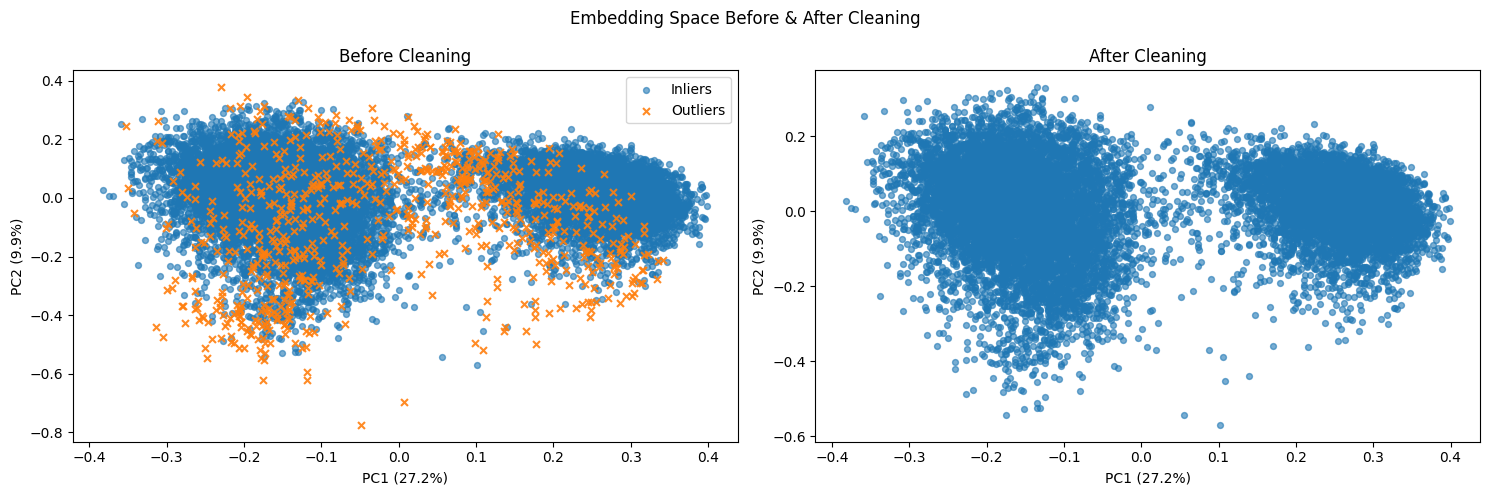

In [11]:
global_outlier_mask = np.zeros(len(df_combine), dtype=bool)
for db in tqdm([0, 1, 2]):
    for ds in [0, 1]:
        subset = (df_combine["db"] == db) & (df_combine["disease_status"] == ds)
        idx = np.where(subset)[0]
        if len(idx) == 0:
            continue

        mask_local = get_outlier_mask(df_combine[subset], contamination=0.05)
        global_outlier_mask[idx] = mask_local

inlier_mask = ~global_outlier_mask

raw_emb = np.stack(df_combine["embed"].values)
#raw_emb = raw_emb / (np.linalg.norm(raw_emb, axis=1, keepdims=True) + 1e-12)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(raw_emb)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle("Embedding Space Before & After Cleaning")

# BEFORE
ax = axes[0]
ax.scatter(pcs[inlier_mask,0], pcs[inlier_mask,1], s=18, alpha=0.6, label="Inliers")
ax.scatter(pcs[global_outlier_mask,0], pcs[global_outlier_mask,1],
           s=25, alpha=0.9, marker="x", label="Outliers")

ax.set_title("Before Cleaning")
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.legend()

# AFTER
ax = axes[1]
ax.scatter(pcs[inlier_mask,0], pcs[inlier_mask,1], s=18, alpha=0.6)

ax.set_title("After Cleaning")
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")

plt.tight_layout()
plt.show()

In [12]:
#df_combine = df_combine[~global_outlier_mask].reset_index(drop=True)

In [13]:
# summary, model_results = run_embedding_classification(
#     df_combine,
#     train_db=0,
#     test_dbs=[1, 2],
#     label_col="disease_status",
# )
# summary

## COMBAT

In [14]:
emb = np.stack(df_combine["embed"].values)
y = df_combine["db"]
X_train, X_test, y_train, y_test = train_test_split(emb, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"[DB Leakage] Acc: {acc:.4f}, F1: {f1:.4f}")

[DB Leakage] Acc: 1.0000, F1: 1.0000


In [15]:
raw_emb = np.stack(df_combine['embed'].values)
#raw_emb = raw_emb / (np.linalg.norm(raw_emb, axis=1, keepdims=True) + 1e-12)
db_labels = df_combine['db'].values
disease_labels = df_combine['disease_status'].values

N, D = raw_emb.shape
print(f"  Embeddings: {N} samples × {D} dims")
print(f"  Databases : {dict(zip(*np.unique(db_labels, return_counts=True)))}")
print(f"  Disease   : {dict(zip(*np.unique(disease_labels, return_counts=True)))}")

  Embeddings: 14527 samples × 4096 dims
  Databases : {0: 8815, 1: 5237, 2: 475}
  Disease   : {0: 10548, 1: 3979}


In [16]:
covariates = disease_labels.astype(float).reshape(-1, 1)
combat_emb = combat_harmonize(raw_emb, db_labels, covariates=None)
embeddings = {"raw": raw_emb, "ComBat": combat_emb}
df_combine["embed"] = list(combat_emb)

# mmd_raw = pairwise_mmd_matrix(raw_emb, db_labels)
# mmd_combat = pairwise_mmd_matrix(combat_emb, db_labels)
# print({
#     "Raw":     mmd_raw.values[mmd_raw.values > 0].mean(),
#     "ComBat":  mmd_combat.values[mmd_combat.values > 0].mean(),
# })

# r2_result = {}
# for name, emb in embeddings.items():
#     pca = PCA(n_components=50, random_state=42)
#     pcs = pca.fit_transform(emb)

#     r2_db = Ridge().fit(db_labels.reshape(-1, 1), pcs).score(db_labels.reshape(-1, 1), pcs)
#     r2_dis = Ridge().fit(disease_labels.reshape(-1, 1), pcs).score(disease_labels.reshape(-1, 1), pcs)
#     r2_result[name] = {
#         "r2_db": r2_db,
#         "r2_dis": r2_dis,
#     }
# r2_result

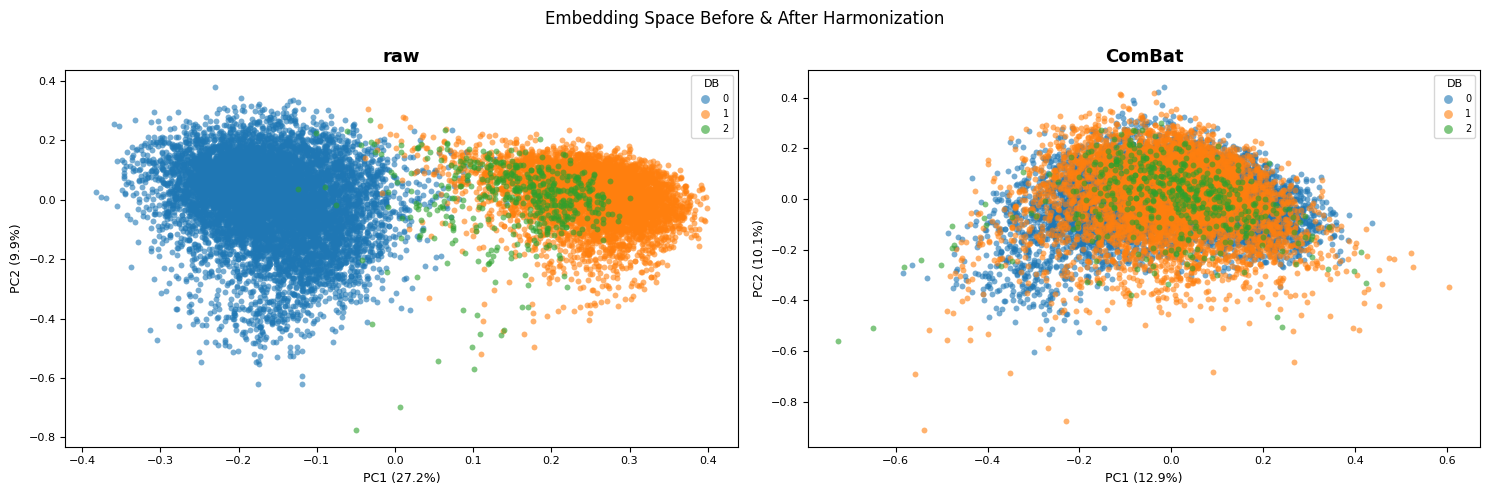

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Embedding Space Before & After Harmonization")

for col, (name, emb) in enumerate(embeddings.items()):
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(emb)
    var1, var2 = pca.explained_variance_ratio_ * 100

    ax = axes[col]
    unique_dbs = np.unique(db_labels)
    for db in unique_dbs:
        mask = db_labels == db
        ax.scatter(pcs[mask, 0], pcs[mask, 1], label=str(db), alpha=0.6, s=18, linewidths=0)
    ax.set_title(f"{name}", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var1:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var2:.1f}%)", fontsize=9)
    ax.legend(fontsize=7, markerscale=1.5, title="DB", title_fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig.savefig(
    "docs/unsupervised_distri/figures/combat.png",
    dpi=300,
    bbox_inches="tight"
)

In [18]:
# embeddings
emb = np.stack(df_combine["embed"].values)

# optional (keep consistent with your pipeline)
# emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)

y = df_combine["db"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    emb, y, test_size=0.2, random_state=42, stratify=y
)

# classifier
clf = LogisticRegression(max_iter=1000, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"[DB Leakage] Acc: {acc:.4f}, F1: {f1:.4f}")

[DB Leakage] Acc: 0.6067, F1: 0.2517


In [19]:
# summary, model_results = run_embedding_classification(
#     df_combine,
#     train_db=0,
#     test_dbs=[1, 2],
#     label_col="disease_status",
# )
# summary

## Strip Speaker Information

In [20]:
# counts = df_combine["participant"].value_counts()
# valid_speakers = counts[counts >= 3].index
# df_combine = df_combine[df_combine["participant"].isin(valid_speakers)].reset_index(drop=True)

In [21]:
# raw_emb = np.stack(df_combine['embed'].values)

In [22]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, f1_score
# import numpy as np

# # ─────────────────────────────────────────────
# # 1. Train / test split
# # ─────────────────────────────────────────────
# X_train, X_test, y_train, y_test = train_test_split(
#     raw_emb, df_combine["participant"], test_size=0.2, random_state=42, stratify=df_combine["participant"]
# )

# # ─────────────────────────────────────────────
# # 2. Train speaker classifier (before)
# # ─────────────────────────────────────────────
# clf = LogisticRegression(max_iter=1000, n_jobs=-1)
# clf.fit(X_train, y_train)

# y_pred = clf.predict(X_test)

# acc_before = accuracy_score(y_test, y_pred)
# f1_before = f1_score(y_test, y_pred, average="macro")

# print(f"[Before] Speaker Acc: {acc_before:.4f}, F1: {f1_before:.4f}")

# # ─────────────────────────────────────────────
# # 3. Remove speaker subspace
# # ─────────────────────────────────────────────
# W = clf.coef_  # (num_speakers, dim)

# U, S, Vt = np.linalg.svd(W, full_matrices=False)

# proj = Vt.T @ Vt   # (dim, dim)

# emb_clean = raw_emb - raw_emb @ proj

# # ─────────────────────────────────────────────
# # 4. Re-evaluate on cleaned embeddings
# # ─────────────────────────────────────────────
# X_train_c, X_test_c, y_train, y_test = train_test_split(
#     emb_clean, df_combine["participant"], test_size=0.2, random_state=42, stratify=df_combine["participant"]
# )

# clf_clean = LogisticRegression(max_iter=1000, n_jobs=-1)
# clf_clean.fit(X_train_c, y_train)

# y_pred_c = clf_clean.predict(X_test_c)

# acc_after = accuracy_score(y_test, y_pred_c)
# f1_after = f1_score(y_test, y_pred_c, average="macro")

# print(f"[After] Speaker Acc: {acc_after:.4f}, F1: {f1_after:.4f}")

In [23]:
# df_combine["embed"] = list(emb_clean)

## Intra Classs

In [24]:
df_patient = (
    df_combine.groupby("participant")
    .agg({
        "path_file": "first",
        "disease_status": "first",
        "gender": "first",
        "weight_loss": "first",
        "hemoptysis": "first",
        "night_sweats": "first",
        "smoker": "first",
        "db": "first",
        "embed": lambda x: np.mean(np.stack(x.values), axis=0)
    })
    .reset_index()
)


In [25]:
df_current = df_combine
#df_current = df_patient

In [26]:
raw_emb = np.stack(df_current['embed'].values)
db_labels = df_current['db'].values
disease_labels = df_current['disease_status'].values

tb_mask = disease_labels == 1
tb_mask0 = (disease_labels == 1) & (db_labels == 0)
tb_mask1 = (disease_labels== 1) & (db_labels == 1)
tb_mask2 = (disease_labels== 1) & (db_labels == 2)

In [27]:
all_scores = {}
variance_threshold = 0.95
n_components = 50 #20–50 544
#n_components, _ = _auto_pca_components(raw_emb, variance_threshold, 42)
N, D = raw_emb.shape

reducer = PCA(n_components=n_components, random_state=42)
emb_reduced = reducer.fit_transform(raw_emb)

# reducer_umap = umap.UMAP(n_components=50, n_neighbors=15, min_dist=0.0, metric="cosine", random_state=42)
# emb_reduced = reducer_umap.fit_transform(emb_reduced)

tb_emb   = emb_reduced[tb_mask]
nontb_emb = emb_reduced[~tb_mask]

### KNN

k_tb: 2 | k_nontb: 2
  → ✗ UNIMODAL — threshold may be arbitrary
  → ✗ NOT CONSISTENT — subtypes don't separate geometrically (Acoustic-TB purity=47.7%)
Acoustic-TB: 1169 (29.4%) | Label-only-TB: 2810 (70.6%)
Acoustic-TB -> DB 0: 748 (28.4%) | DB 1: 110 (11.8%) | DB 2: 311 (74.6%)



Training classifiers: 100%|██████████| 3/3 [00:42<00:00, 14.04s/it]


{'all': '0.71 ± 0.01', 'db_1': '0.59 ± 0.04', 'db_2': '0.58 ± 0.07'}


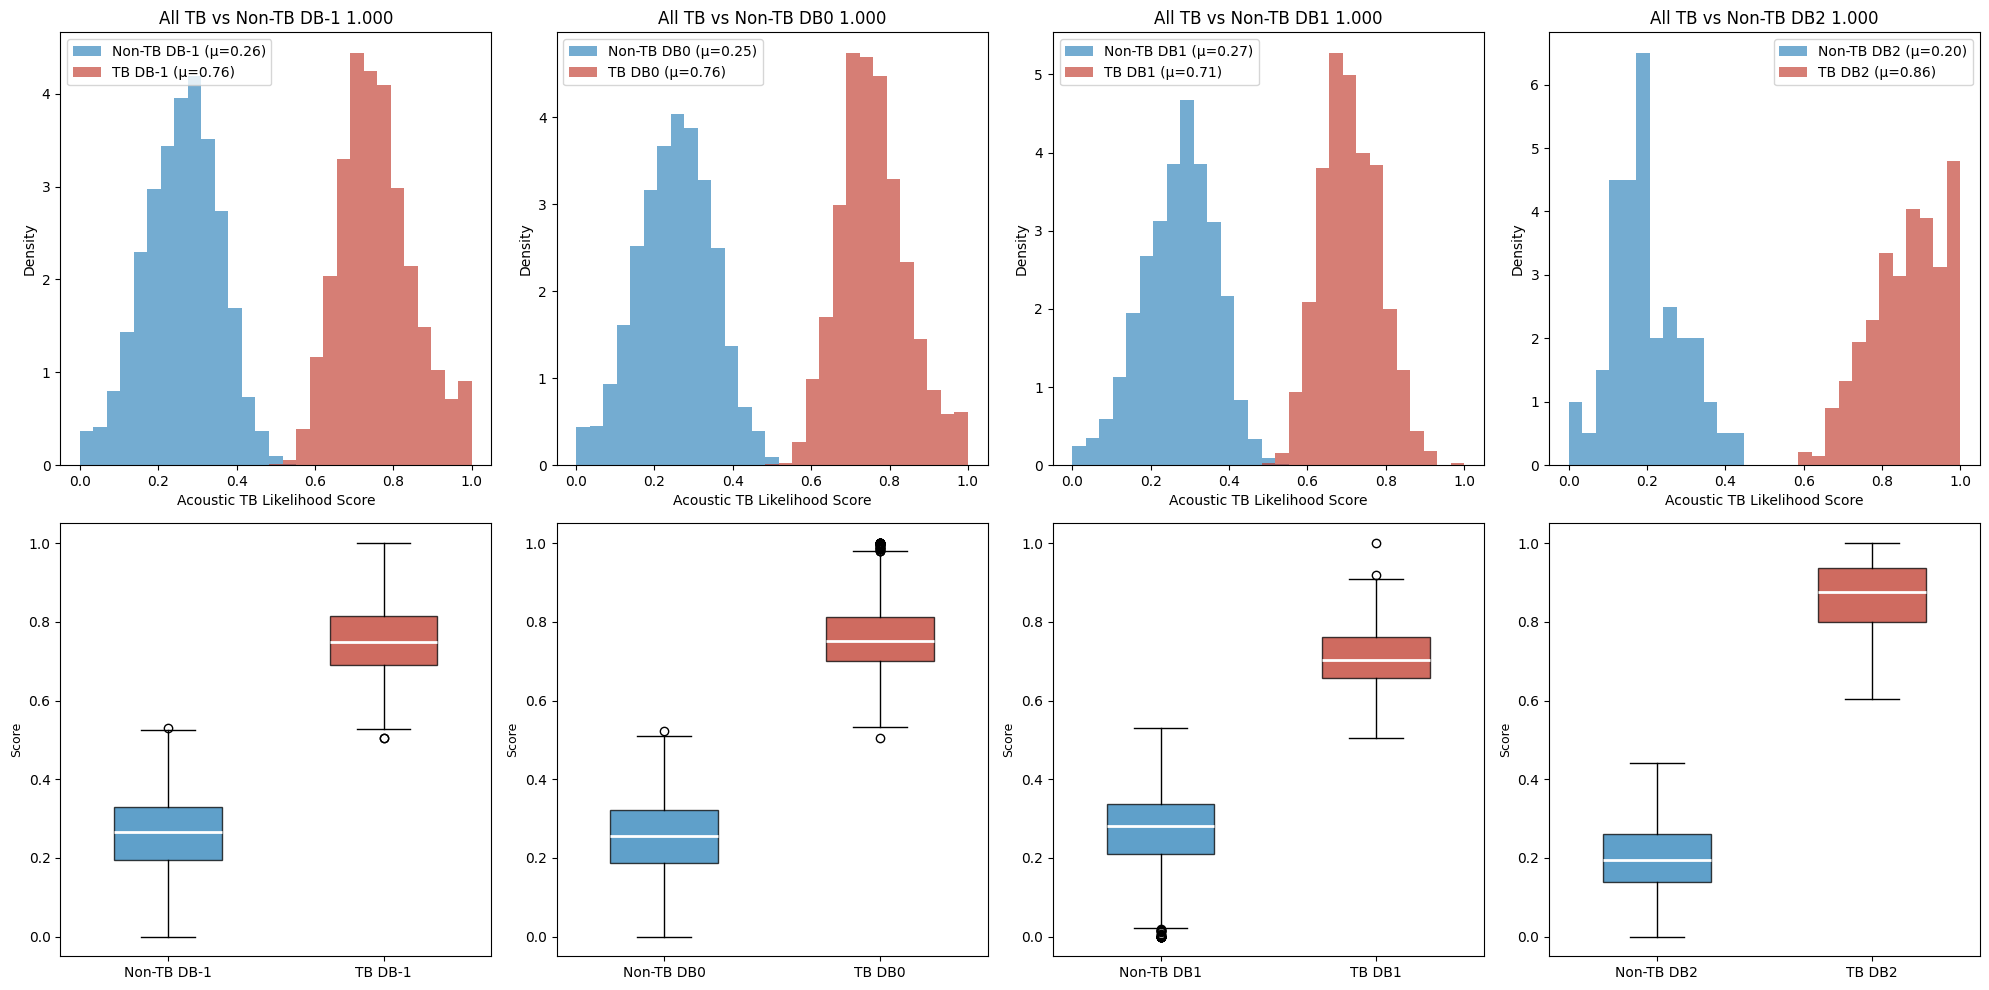

In [28]:
"""
k-Nearest Neighbor distance-based acoustic TB likelihood.

Intuition
---------
For each sample, compute:
    d_TB     = mean distance to its k nearest TB neighbors
    d_NonTB  = mean distance to its k nearest Non-TB neighbors

Score = d_NonTB / (d_TB + d_NonTB)
    → high score = closer to TB neighborhood = likely TB
    → low score  = closer to Non-TB neighborhood = likely Non-TB

Makes NO distributional assumptions. Captures non-linear, multi-modal
cluster structure. Each sample is judged by its local neighborhood,
not a global decision boundary.

Parameters
----------
Bigger K, More Spread to distribution, make it can overrlap each other
k : number of neighbors (15–25 works well for large datasets)
alpha : Balance Density of Each Class, Higher Mean TB ore have coverage, read Sigmoid Function
"""

all_scores["knn_cos"] = knn_tb_score(emb_reduced, tb_mask, automate_k=True, k_tb=50, k_nontb=50, alpha=1, metric="cosine") # k_tb: 3 | k_nontb: 2
validate_acoustic_score_indiv(emb_reduced, disease_labels, all_scores["knn_cos"])
df_temp = evaluate_acoustic_tb(df_current, all_scores["knn_cos"]) 
plot_tb_score_distributions(df_temp, bins=bins, colors=colors)

k_tb: 2 | k_nontb: 2
  → ✓ BIMODAL — two subgroups supported
  → ✗ NOT CONSISTENT — subtypes don't separate geometrically (Acoustic-TB purity=47.7%)
Acoustic-TB: 1612 (40.5%) | Label-only-TB: 2367 (59.5%)
Acoustic-TB -> DB 0: 1131 (43.0%) | DB 1: 185 (19.9%) | DB 2: 296 (71.0%)



Training classifiers: 100%|██████████| 3/3 [00:42<00:00, 14.14s/it]


{'all': '0.73 ± 0.02', 'db_1': '0.60 ± 0.08', 'db_2': '0.56 ± 0.06'}


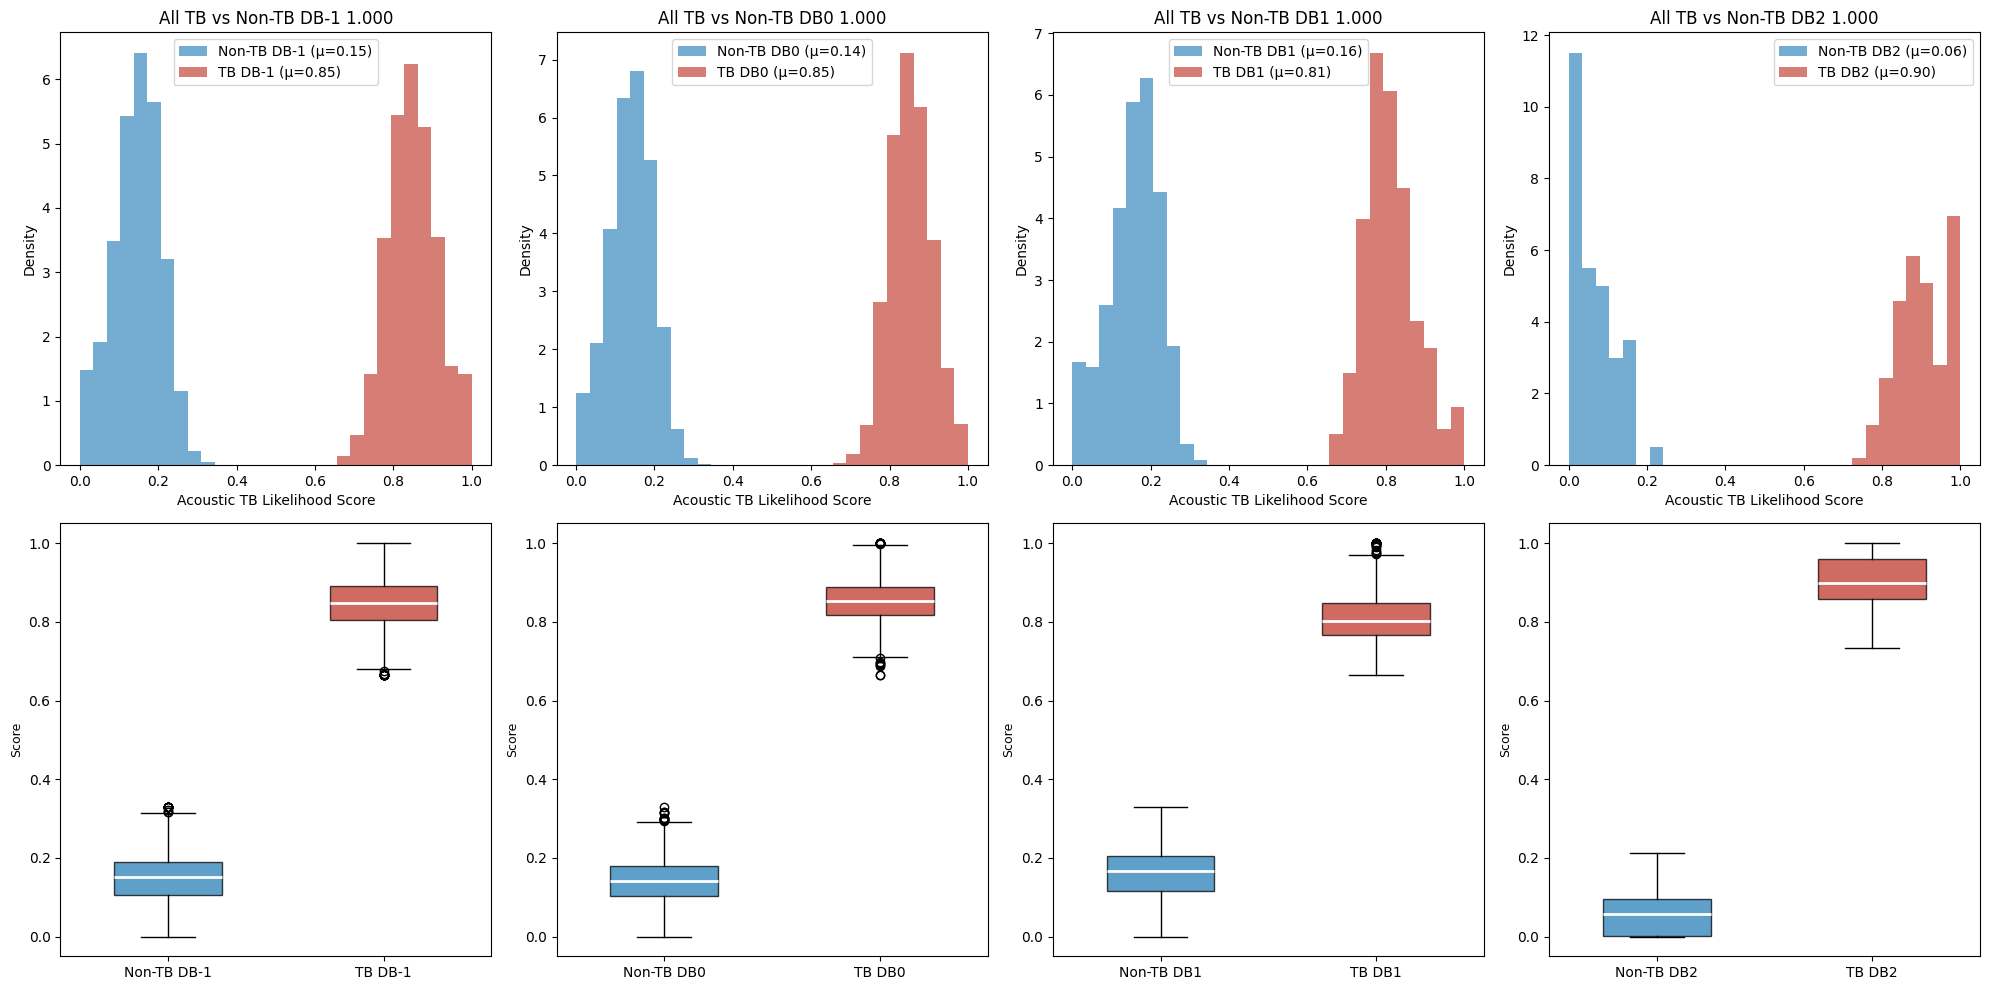

In [29]:
all_scores["knn_euc"] = knn_tb_score(emb_reduced, tb_mask, automate_k=False, k_tb=2, k_nontb=2, alpha=6.5, metric="euclidean") # k_tb: 3 | k_nontb: 2
validate_acoustic_score_indiv(emb_reduced, disease_labels, all_scores["knn_euc"])
df_temp = evaluate_acoustic_tb(df_current, all_scores["knn_euc"])
plot_tb_score_distributions(df_temp, bins=bins, colors=colors)

### Mixture

      DPGMM TB: 1/4 active components
      DPGMM NonTB: 2/4 active components
  → ✓ BIMODAL — two subgroups supported
  → ✗ NOT CONSISTENT — subtypes don't separate geometrically (Acoustic-TB purity=31.6%)
Acoustic-TB: 850 (21.4%) | Label-only-TB: 3129 (78.6%)
Acoustic-TB -> DB 0: 713 (27.1%) | DB 1: 108 (11.6%) | DB 2: 29 (7.0%)



Training classifiers: 100%|██████████| 3/3 [00:39<00:00, 13.31s/it]


{'all': '0.90 ± 0.01', 'db_1': '0.71 ± 0.04', 'db_2': '0.73 ± 0.03'}


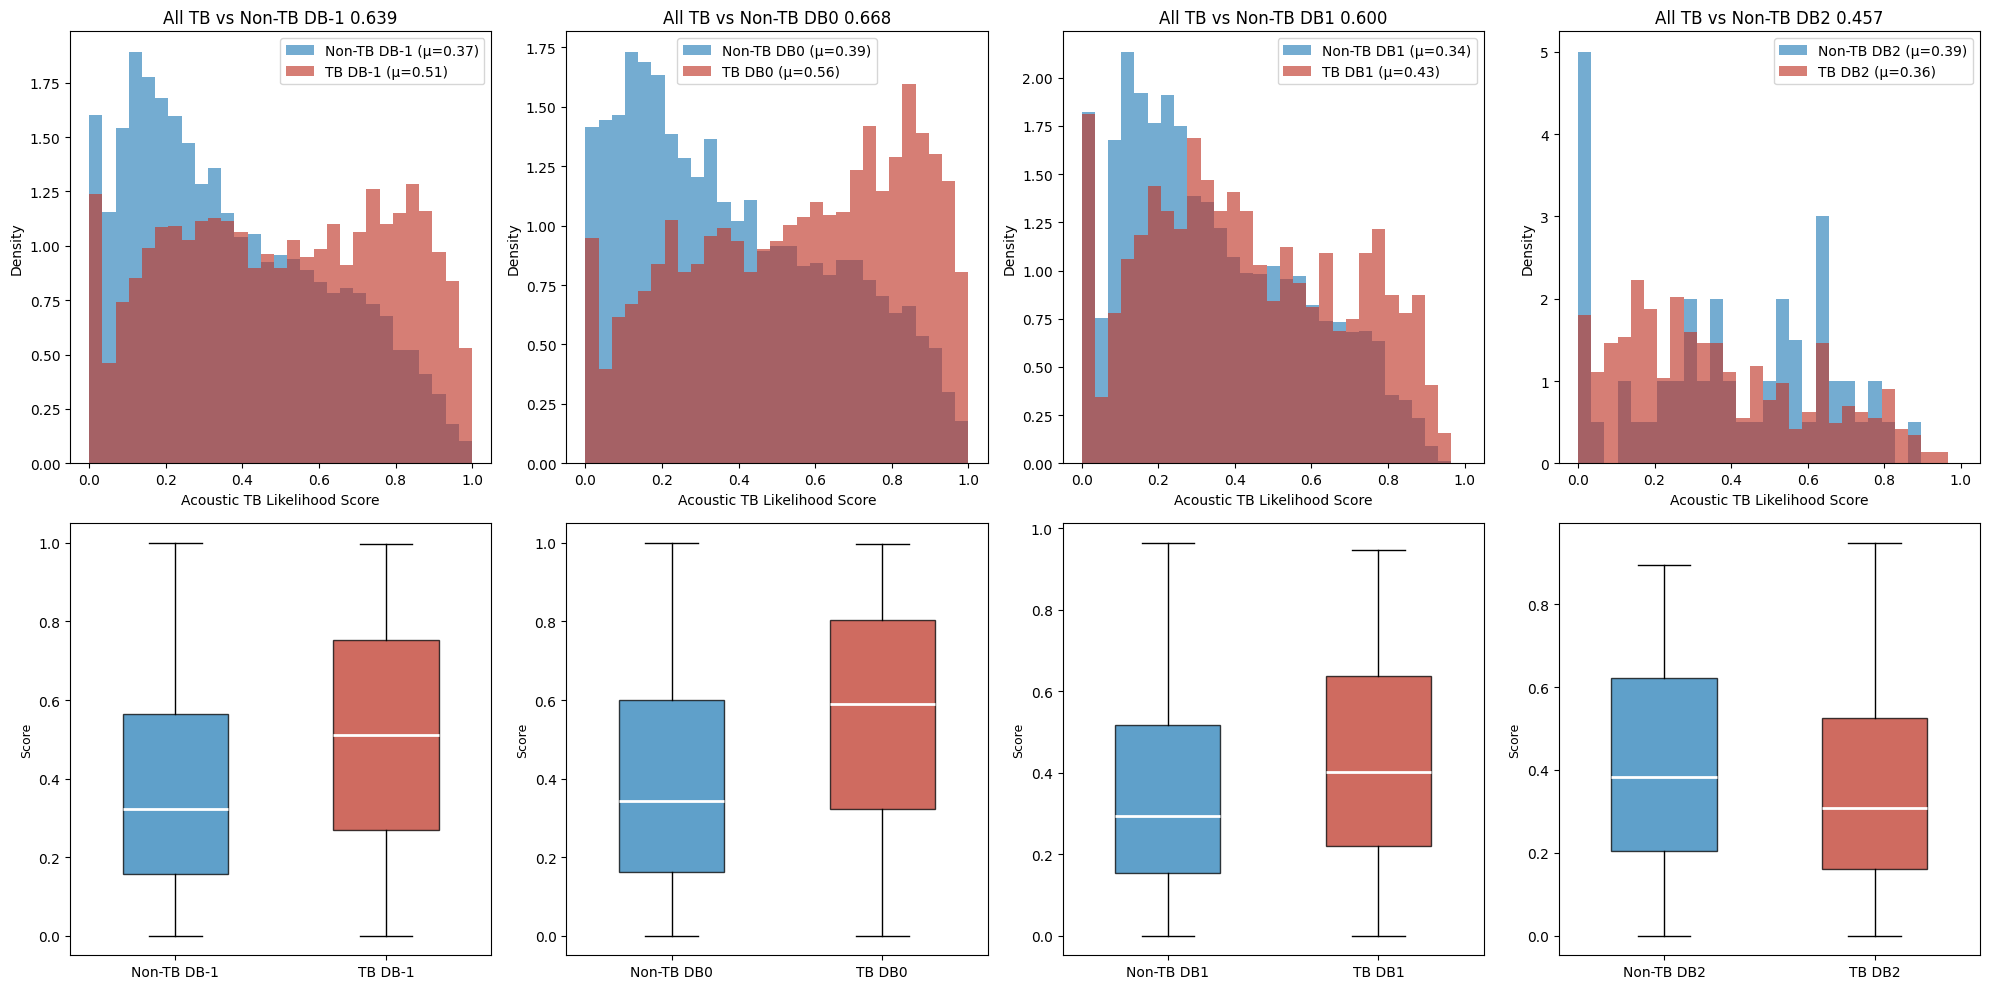

In [30]:
"""
Bayesian GMM posterior P(TB|x) via Dirichlet Process GMM.

Unlike standard GMM where n_components is selected via BIC grid search,
DPGMM places a Dirichlet Process prior over mixture weights — components
with no supporting data automatically collapse to zero weight.
The model infers the effective number of components from the data.

Advantage over GMM for TB:
    - No manual BIC search, fewer hyperparameters
    - Naturally regularized — avoids overfitting when TB subgroup is small
    - More robust when TB has unknown number of acoustic subtypes

max_components : upper bound on components (DPGMM won't use all of them)
"""

from sklearn.mixture import BayesianGaussianMixture

def fit_dpgmm(data, label):
    max_components = 4
    n_comp = min(max_components, len(data) // 10)
    m = BayesianGaussianMixture(
        n_components=n_comp,
        covariance_type="diag",
        weight_concentration_prior_type="dirichlet_process",
        weight_concentration_prior=1e-2,   # low → fewer active components
        random_state=42, n_init=10, max_iter=200,
    )
    m.fit(data)
    active = (m.weights_ > 1e-3).sum()
    print(f"      DPGMM {label}: {active}/{n_comp} active components")
    return m

gmm_tb    = fit_dpgmm(tb_emb,  "TB")
gmm_nontb = fit_dpgmm(nontb_emb, "NonTB")

log_p_tb    = gmm_tb.score_samples(emb_reduced)
log_p_nontb = gmm_nontb.score_samples(emb_reduced)

all_scores["bgmm"] = _minmax_normalize(_posterior(log_p_tb, log_p_nontb))
validate_acoustic_score_indiv(emb_reduced, disease_labels, all_scores["bgmm"])
df_temp = evaluate_acoustic_tb(df_current, all_scores["bgmm"])
plot_tb_score_distributions(df_temp, bins=bins, colors=colors)

  → ✗ UNIMODAL — threshold may be arbitrary
  → ✓ GEOMETRICALLY CONSISTENT — Acoustic-TB clusters with itself (42.7%), Label-only-TB mixes with Non-TB (55.5%)
Acoustic-TB: 974 (24.5%) | Label-only-TB: 3005 (75.5%)
Acoustic-TB -> DB 0: 818 (31.1%) | DB 1: 117 (12.6%) | DB 2: 39 (9.4%)



Training classifiers: 100%|██████████| 3/3 [00:50<00:00, 16.95s/it]


{'all': '0.93 ± 0.01', 'db_1': '0.72 ± 0.05', 'db_2': '0.81 ± 0.03'}


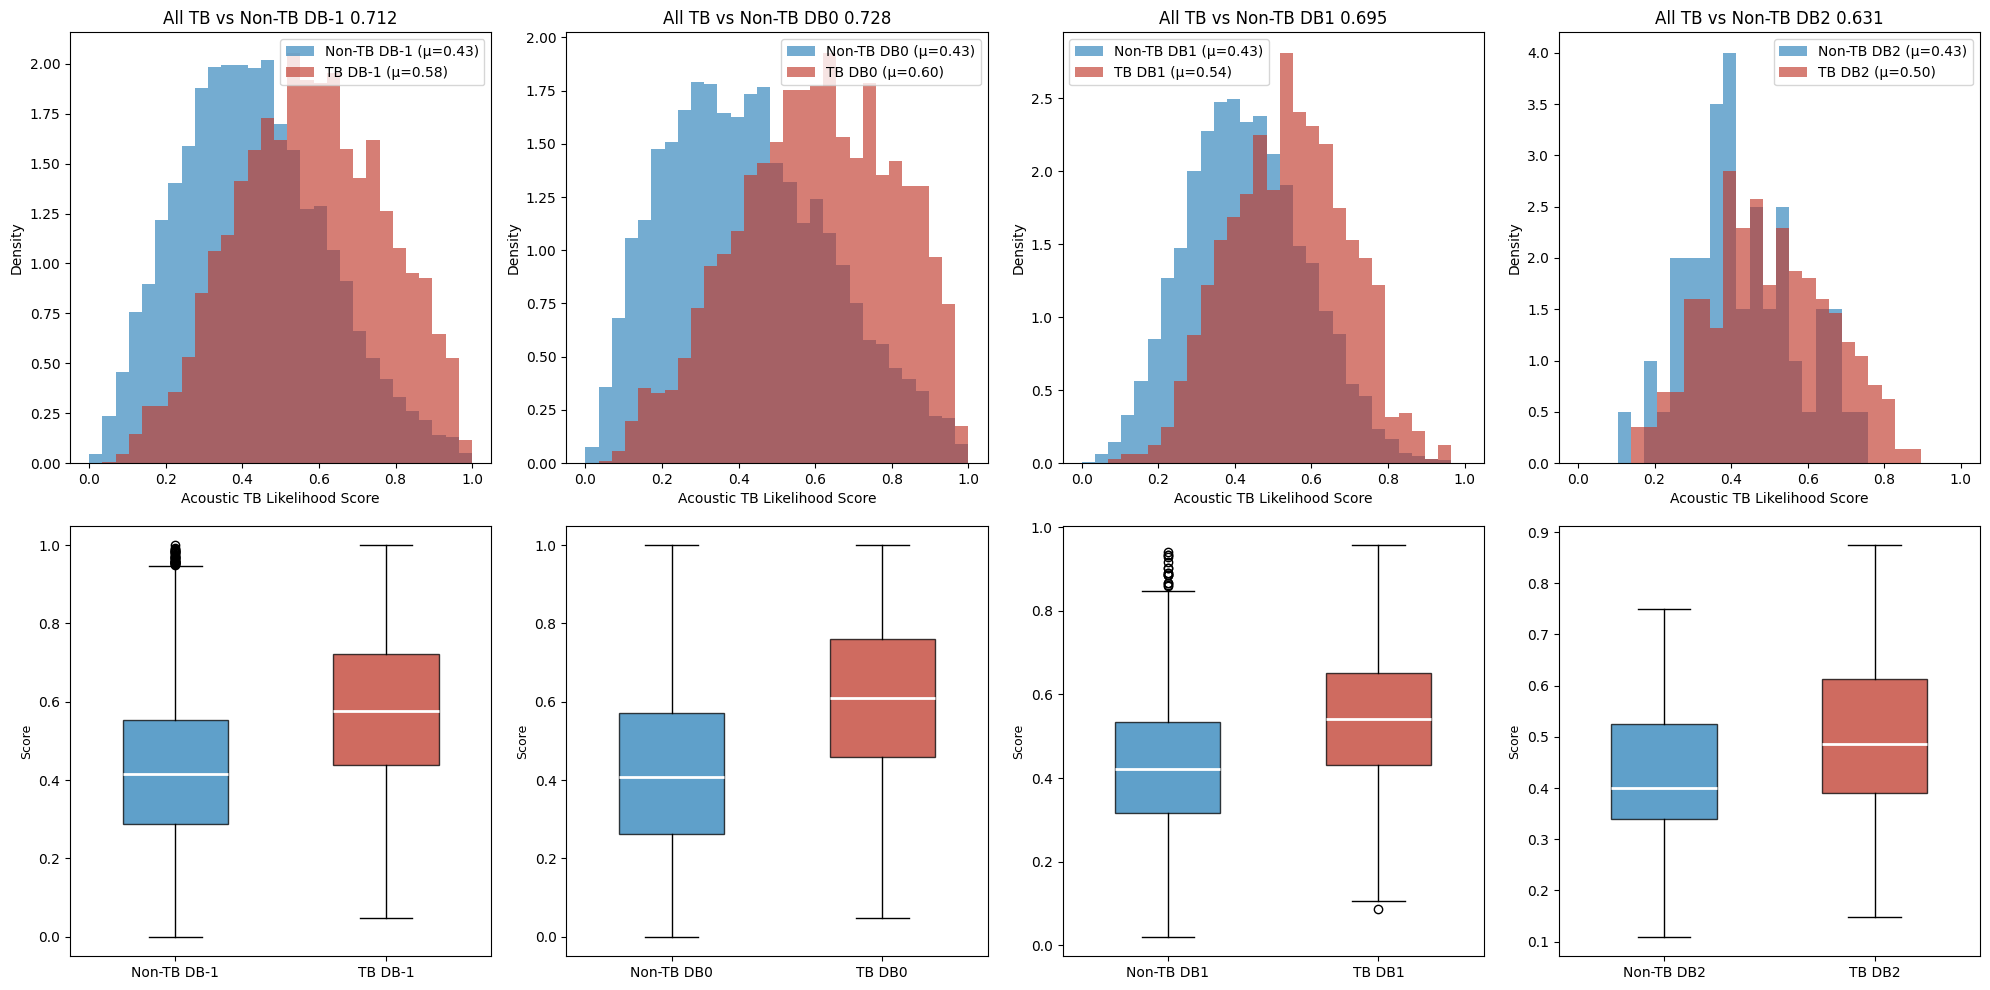

In [31]:
"""
Gaussian Likelihood Ratio: log P(x|TB) - log P(x|NonTB).

Fits a single full-covariance Gaussian per class (QDA-style).
Score = P(TB|x) posterior assuming equal priors.

Simpler than GMM — one Gaussian per class, closed form, very fast.
Equivalent to QDA's scoring function without the classification boundary.
Good baseline: if TB and NonTB are unimodal in PCA space, this is optimal.
If they're multi-modal, GMM/DPGMM will outperform it.

Uses diagonal covariance for stability in high dimensions.
Falls back to spherical if diagonal is still singular.
"""
def fit_single_gaussian(data):
    g = GaussianMixture(n_components=1, covariance_type="diag", random_state=42, n_init=3)
    g.fit(data)
    return g

g_tb    = fit_single_gaussian(tb_emb)
g_nontb = fit_single_gaussian(nontb_emb)

log_p_tb    = g_tb.score_samples(emb_reduced)
log_p_nontb = g_nontb.score_samples(emb_reduced)

all_scores["glr"] = _minmax_normalize(_posterior(log_p_tb, log_p_nontb))
validate_acoustic_score_indiv(emb_reduced, disease_labels, all_scores["glr"])
df_temp = evaluate_acoustic_tb(df_current, all_scores["glr"])
plot_tb_score_distributions(df_temp, bins=bins, colors=colors)

100%|██████████| 1/1 [00:00<00:00,  3.50it/s]


    GMM components selected (BIC): 1


100%|██████████| 1/1 [00:00<00:00,  3.38it/s]


    GMM components selected (BIC): 1
  → ✗ UNIMODAL — threshold may be arbitrary
  → ✓ GEOMETRICALLY CONSISTENT — Acoustic-TB clusters with itself (42.7%), Label-only-TB mixes with Non-TB (55.5%)
Acoustic-TB: 974 (24.5%) | Label-only-TB: 3005 (75.5%)
Acoustic-TB -> DB 0: 818 (31.1%) | DB 1: 117 (12.6%) | DB 2: 39 (9.4%)



Training classifiers: 100%|██████████| 3/3 [00:49<00:00, 16.65s/it]


{'all': '0.93 ± 0.01', 'db_1': '0.72 ± 0.05', 'db_2': '0.81 ± 0.03'}


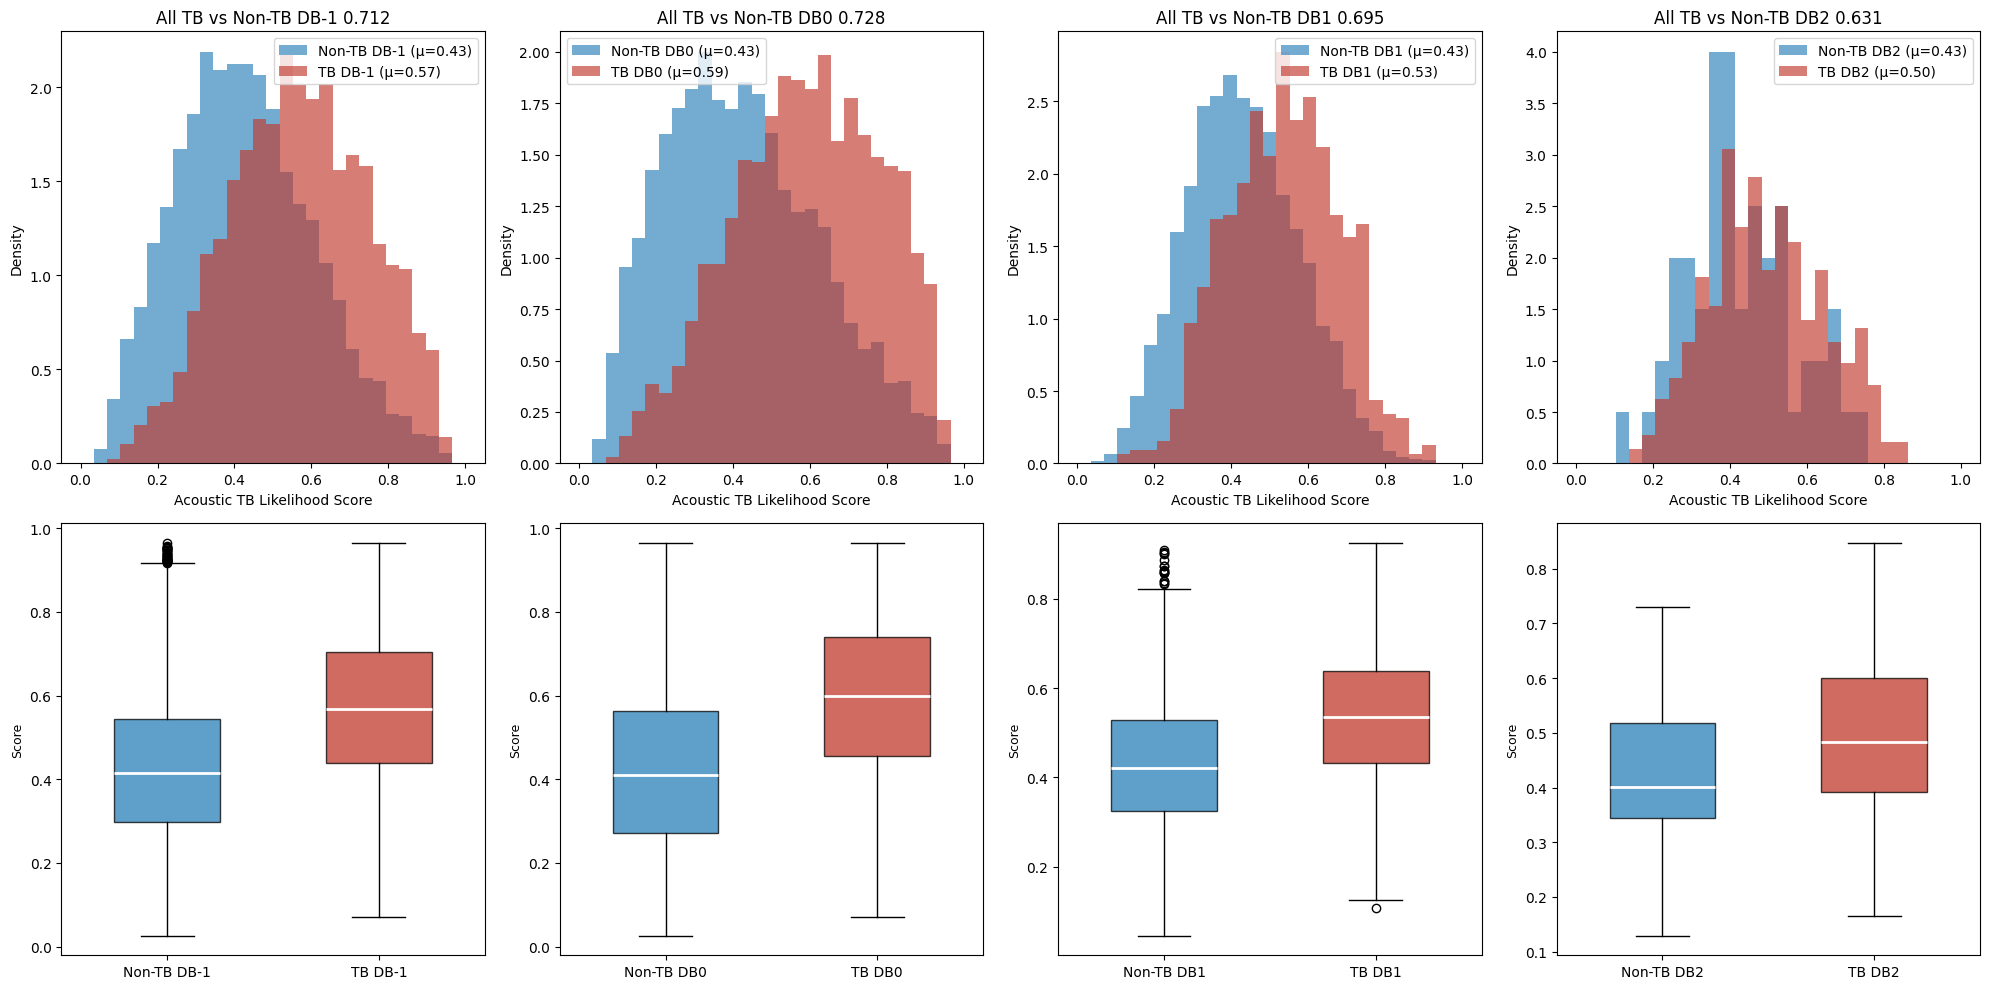

In [32]:
"""
Gaussian Mixture Model posterior: P(TB | x).

Intuition
---------
Fit a separate GMM on TB samples and on Non-TB samples.
Each GMM models the multi-modal, non-linear structure of its class.
Score = P(x | GMM_TB) / (P(x | GMM_TB) + P(x | GMM_NonTB))
        = Bayesian posterior P(TB | x) assuming equal class priors.

Unlike LDA, this:
    - Handles multi-modal distributions (multiple acoustic TB subtypes)
    - Captures non-linear cluster shapes via mixture of Gaussians
    - Gives a proper probabilistic score with Bayesian interpretation

n_components auto-selected via BIC if not provided.

Parameters
----------
n_components_tb    : GMM components for TB class (None = auto via BIC)
n_components_nontb : GMM components for Non-TB class (None = auto via BIC)
"""
gmm_tb = best_gmm(tb_emb, max_k=1, random_state=42)
gmm_nontb = best_gmm(nontb_emb, max_k=1, random_state=42)

# Log-likelihoods
log_p_tb    = gmm_tb.score_samples(emb_reduced)    # (N,) log P(x | TB)
log_p_nontb = gmm_nontb.score_samples(emb_reduced) # (N,) log P(x | Non-TB)

# # Stable log-sum-exp for posterior
# # P(TB|x) = exp(log_p_tb) / (exp(log_p_tb) + exp(log_p_nontb)) , The probability that the sample has TB given the observed data x
# log_max = np.maximum(log_p_tb, log_p_nontb)
# posterior_tb = np.exp(log_p_tb - log_max) / (np.exp(log_p_tb - log_max) + np.exp(log_p_nontb - log_max) + 1e-8)
# posterior_tb = posterior_tb.astype(np.float32)
posterior_tb = _posterior(log_p_tb, log_p_nontb) 
all_scores["gmm"] = posterior_tb
validate_acoustic_score_indiv(emb_reduced, disease_labels, all_scores["gmm"])
df_temp = evaluate_acoustic_tb(df_current, all_scores["gmm"])
plot_tb_score_distributions(df_temp, bins=bins, colors=colors)

### NF

100%|██████████| 50/50 [00:06<00:00,  7.16it/s]


  → ✓ BIMODAL — two subgroups supported
  → ✓ GEOMETRICALLY CONSISTENT — Acoustic-TB clusters with itself (46.8%), Label-only-TB mixes with Non-TB (72.9%)
Acoustic-TB: 2602 (65.4%) | Label-only-TB: 1377 (34.6%)
Acoustic-TB -> DB 0: 1805 (68.6%) | DB 1: 428 (46.1%) | DB 2: 369 (88.5%)



Training classifiers: 100%|██████████| 3/3 [00:51<00:00, 17.19s/it]


{'all': '0.72 ± 0.03', 'db_1': '0.56 ± 0.02', 'db_2': '0.48 ± 0.06'}


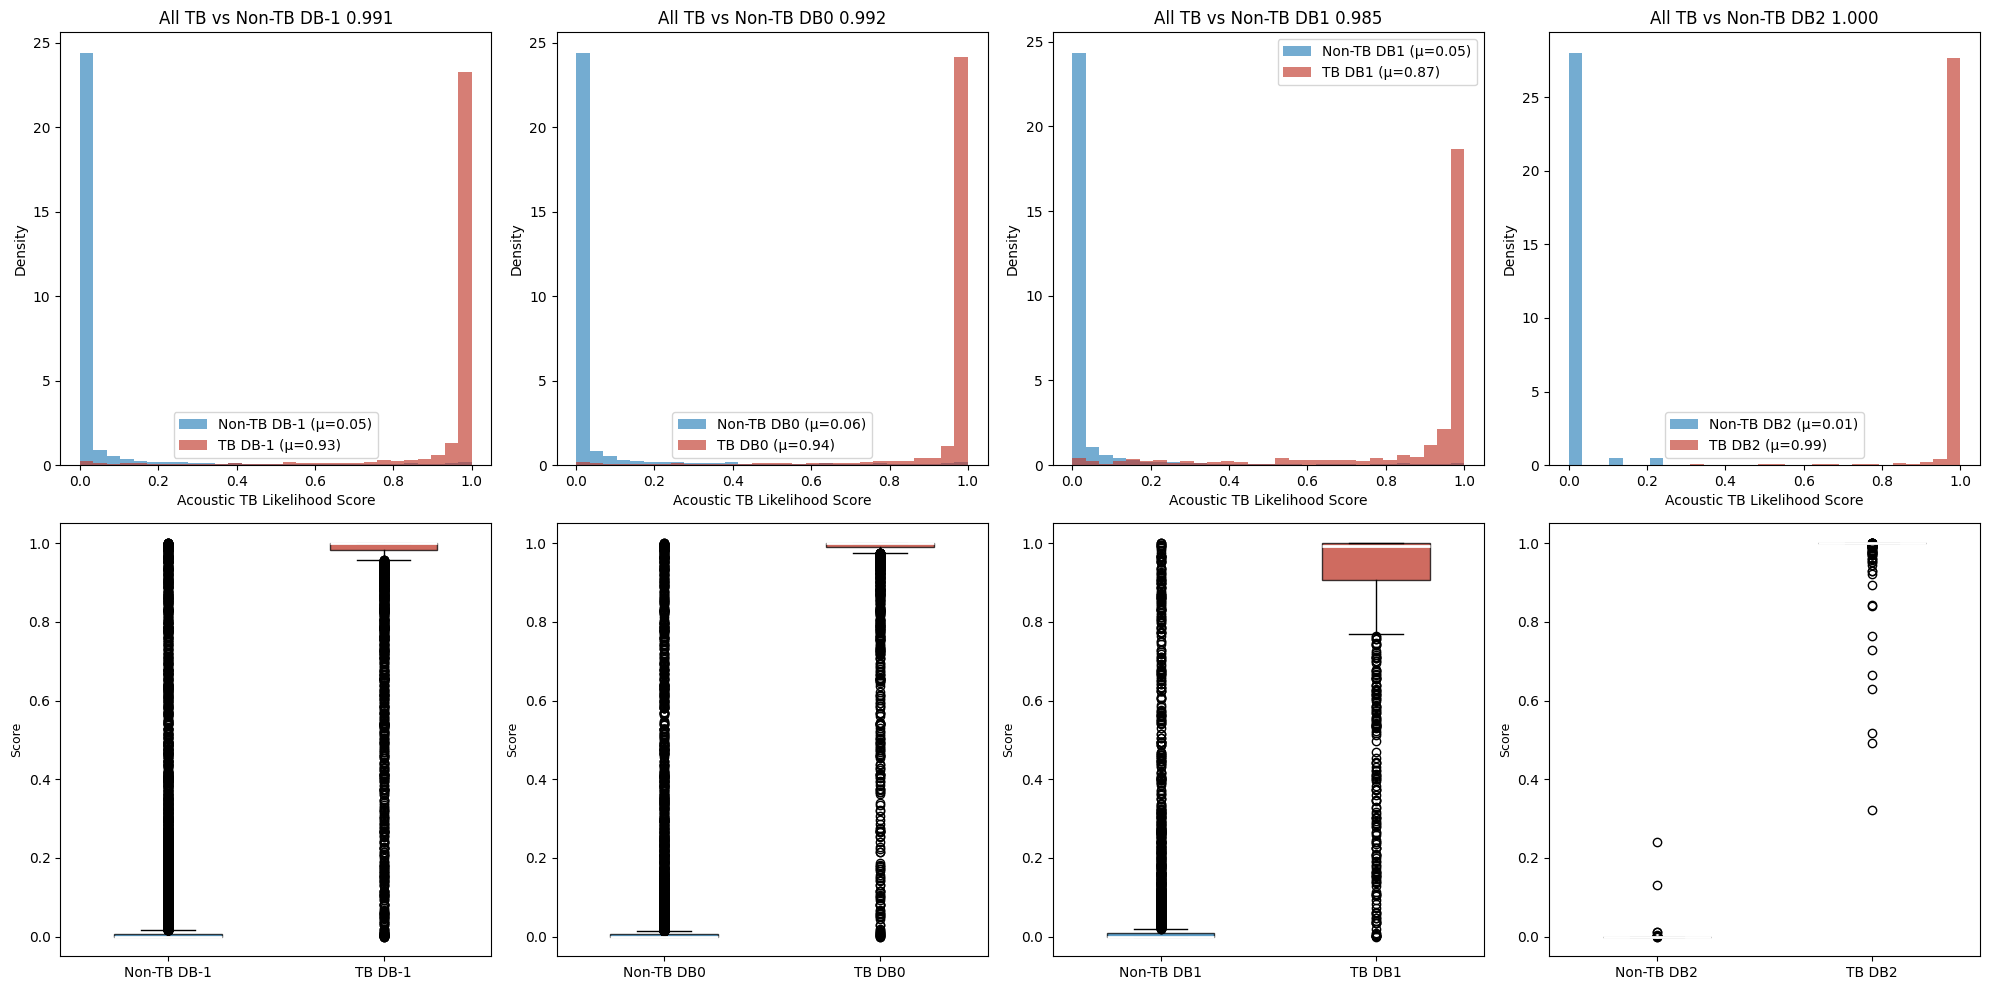

In [33]:
"""
Normalizing Flow density ratio score.

Learns invertible transformations (RealNVP-style affine coupling layers)
that map each class distribution to a standard Gaussian.
Score = log p_TB(x) - log p_NonTB(x) via the learned densities.

Advantage: most expressive density estimator here — no Gaussian assumption,
captures complex non-linear structure that GMM/KDE miss.

⚠ REQUIRES TRAINING — unlike all other methods, this trains a small neural
network (n_flows coupling layers). Uses PyTorch if available, otherwise
falls back to a diagonal Gaussian approximation with a warning.

⚠ HIGH-DIM INSTABILITY — flows are unstable in >20 dims. Auto PCA to
pca_components (or auto-selected) before fitting is essential.

Parameters
----------
n_flows    : number of affine coupling layers (more = more expressive)
hidden_dim : hidden units per coupling layer
n_epochs   : training epochs (50 is usually sufficient for this dim)
lr         : learning rate
"""
n_epochs = 50
n_flows = 2
hidden_dim = 512
lr = 1e-3

D = emb_reduced.shape[1]
torch.manual_seed(42)
device = torch.device("cpu")

def train_flow(data_np, label):
    data = torch.tensor(data_np, dtype=torch.float32, device=device)
    mu  = data.mean(0, keepdim=True)
    sig = data.std(0, keepdim=True).clamp(min=1e-6)
    data_norm = (data - mu) / sig

    flow = RealNVP(D, n_flows, hidden_dim).to(device)
    optimizer = optim.Adam(flow.parameters(), lr=lr)

    for _ in tqdm(range(n_epochs)):
        optimizer.zero_grad()
        loss = -flow.log_prob(data_norm).mean()
        loss.backward()
        nn.utils.clip_grad_norm_(flow.parameters(), 1.0)
        optimizer.step()
    return flow, mu, sig

flow_tb,    mu_tb,    sig_tb    = train_flow(tb_emb,  "TB")
flow_nontb, mu_nontb, sig_nontb = train_flow(nontb_emb, "NonTB")

all_emb = torch.tensor(emb_reduced, dtype=torch.float32)
with torch.no_grad():
    log_p_tb    = flow_tb.log_prob((all_emb - mu_tb) / sig_tb.clamp(min=1e-6)).numpy()
    log_p_nontb = flow_nontb.log_prob((all_emb - mu_nontb) / sig_nontb.clamp(min=1e-6)).numpy()

all_scores["nflow"] = _minmax_normalize(_posterior(log_p_tb, log_p_nontb))
validate_acoustic_score_indiv(emb_reduced, disease_labels, all_scores["nflow"])
df_temp = evaluate_acoustic_tb(df_current, all_scores["nflow"])
plot_tb_score_distributions(df_temp, bins=bins, colors=colors)

  → ✗ UNIMODAL — threshold may be arbitrary
  → ✗ NOT CONSISTENT — subtypes don't separate geometrically (Acoustic-TB purity=29.6%)
Acoustic-TB: 1030 (25.9%) | Label-only-TB: 2949 (74.1%)
Acoustic-TB -> DB 0: 760 (28.9%) | DB 1: 105 (11.3%) | DB 2: 165 (39.6%)



Training classifiers: 100%|██████████| 3/3 [00:40<00:00, 13.52s/it]


{'all': '0.90 ± 0.01', 'db_1': '0.50 ± 0.01', 'db_2': '0.74 ± 0.04'}


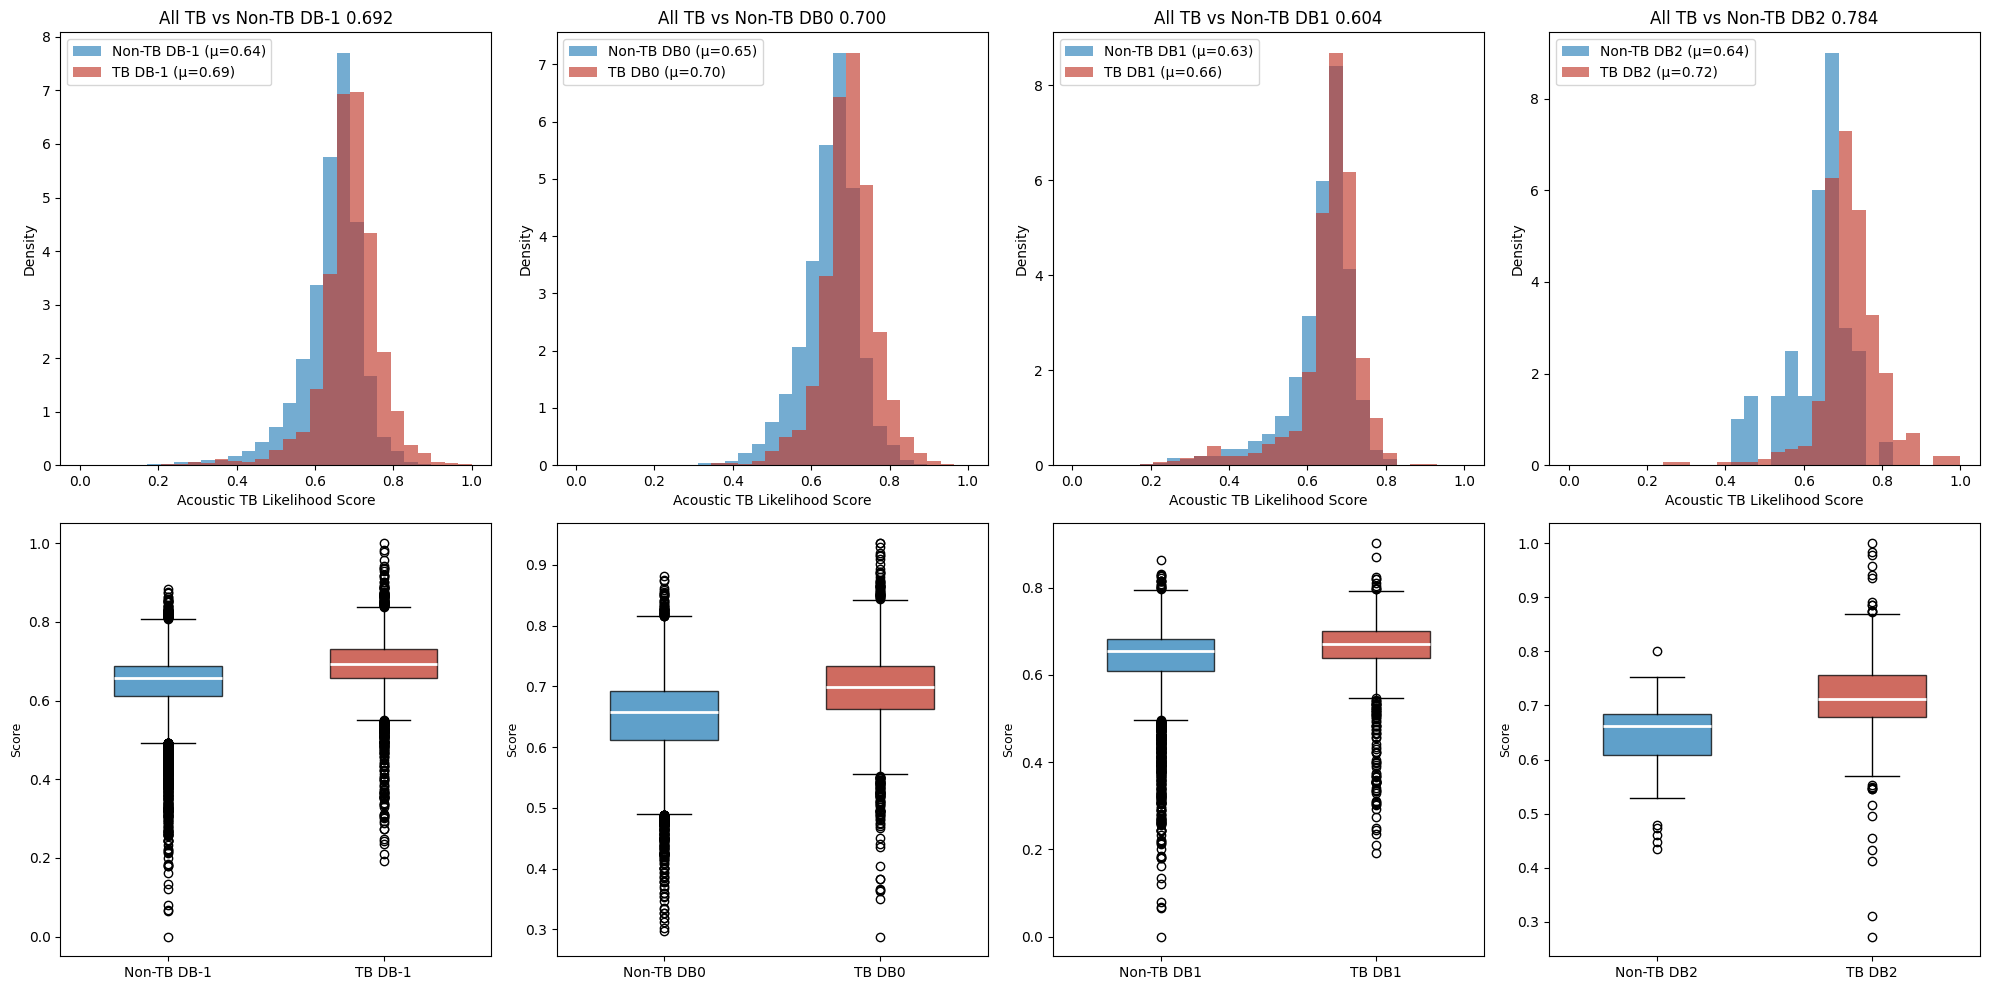

In [43]:
"""
LOF fitted on Non-TB only — anomaly w.r.t. Non-TB distribution.

High score → sample is isolated relative to its Non-TB neighborhood
            → likely not a typical Non-TB cough → possibly TB.
"""
n_neighbors = 50

lof_tb = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True, n_jobs=-1)
lof_ntb = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True, n_jobs=-1)

lof_tb.fit(tb_emb)
lof_ntb.fit(nontb_emb)

score_tb = lof_tb.score_samples(emb_reduced)      # density relative to TB
score_ntb = lof_ntb.score_samples(emb_reduced)    # density relative to Non-TB

# margin = score_tb - score_ntb
# alpha = 8
# scores = 1 / (1 + np.exp(-alpha * margin))           # sigmoid shaping
#all_scores["lof_margin"] = _minmax_normalize(scores)
all_scores["lof_margin"] = _minmax_normalize(_posterior(score_tb, score_ntb))
validate_acoustic_score_indiv(emb_reduced, disease_labels, all_scores["lof_margin"])
df_temp = evaluate_acoustic_tb(df_current, all_scores["lof_margin"])
plot_tb_score_distributions(df_temp, bins=bins, colors=colors)

In [35]:
# Per-method breakdown
for m, s in all_scores.items():
    if m == "ensemble": continue
    print(f"  [{m}] TB: {s[tb_mask].mean():.3f} ± {s[tb_mask].std():.3f} | " f"Non-TB: {s[~tb_mask].mean():.3f} ± {s[~tb_mask].std():.3f}")

  [knn_cos] TB: 0.758 ± 0.094 | Non-TB: 0.261 ± 0.094
  [knn_euc] TB: 0.849 ± 0.064 | Non-TB: 0.146 ± 0.062
  [bgmm] TB: 0.505 ± 0.281 | Non-TB: 0.371 ± 0.253
  [glr] TB: 0.577 ± 0.190 | Non-TB: 0.427 ± 0.189
  [gmm] TB: 0.568 ± 0.179 | Non-TB: 0.428 ± 0.178
  [nflow] TB: 0.932 ± 0.188 | Non-TB: 0.054 ± 0.170
  [lof_margin] TB: 0.634 ± 0.062 | Non-TB: 0.493 ± 0.075


  → ✗ UNIMODAL — threshold may be arbitrary
  → ✓ GEOMETRICALLY CONSISTENT — Acoustic-TB clusters with itself (45.2%), Label-only-TB mixes with Non-TB (56.9%)
 Return to Percentile Threshold
 Return to Percentile Threshold
Acoustic-TB: 1226 (30.8%) | Label-only-TB: 2753 (69.2%)
Acoustic-TB -> DB 0: 960 (36.5%) | DB 1: 157 (16.9%) | DB 2: 109 (26.1%)



Training classifiers: 100%|██████████| 3/3 [00:43<00:00, 14.45s/it]


{'all': '0.92 ± 0.01', 'db_1': '0.71 ± 0.01', 'db_2': '0.79 ± 0.05'}


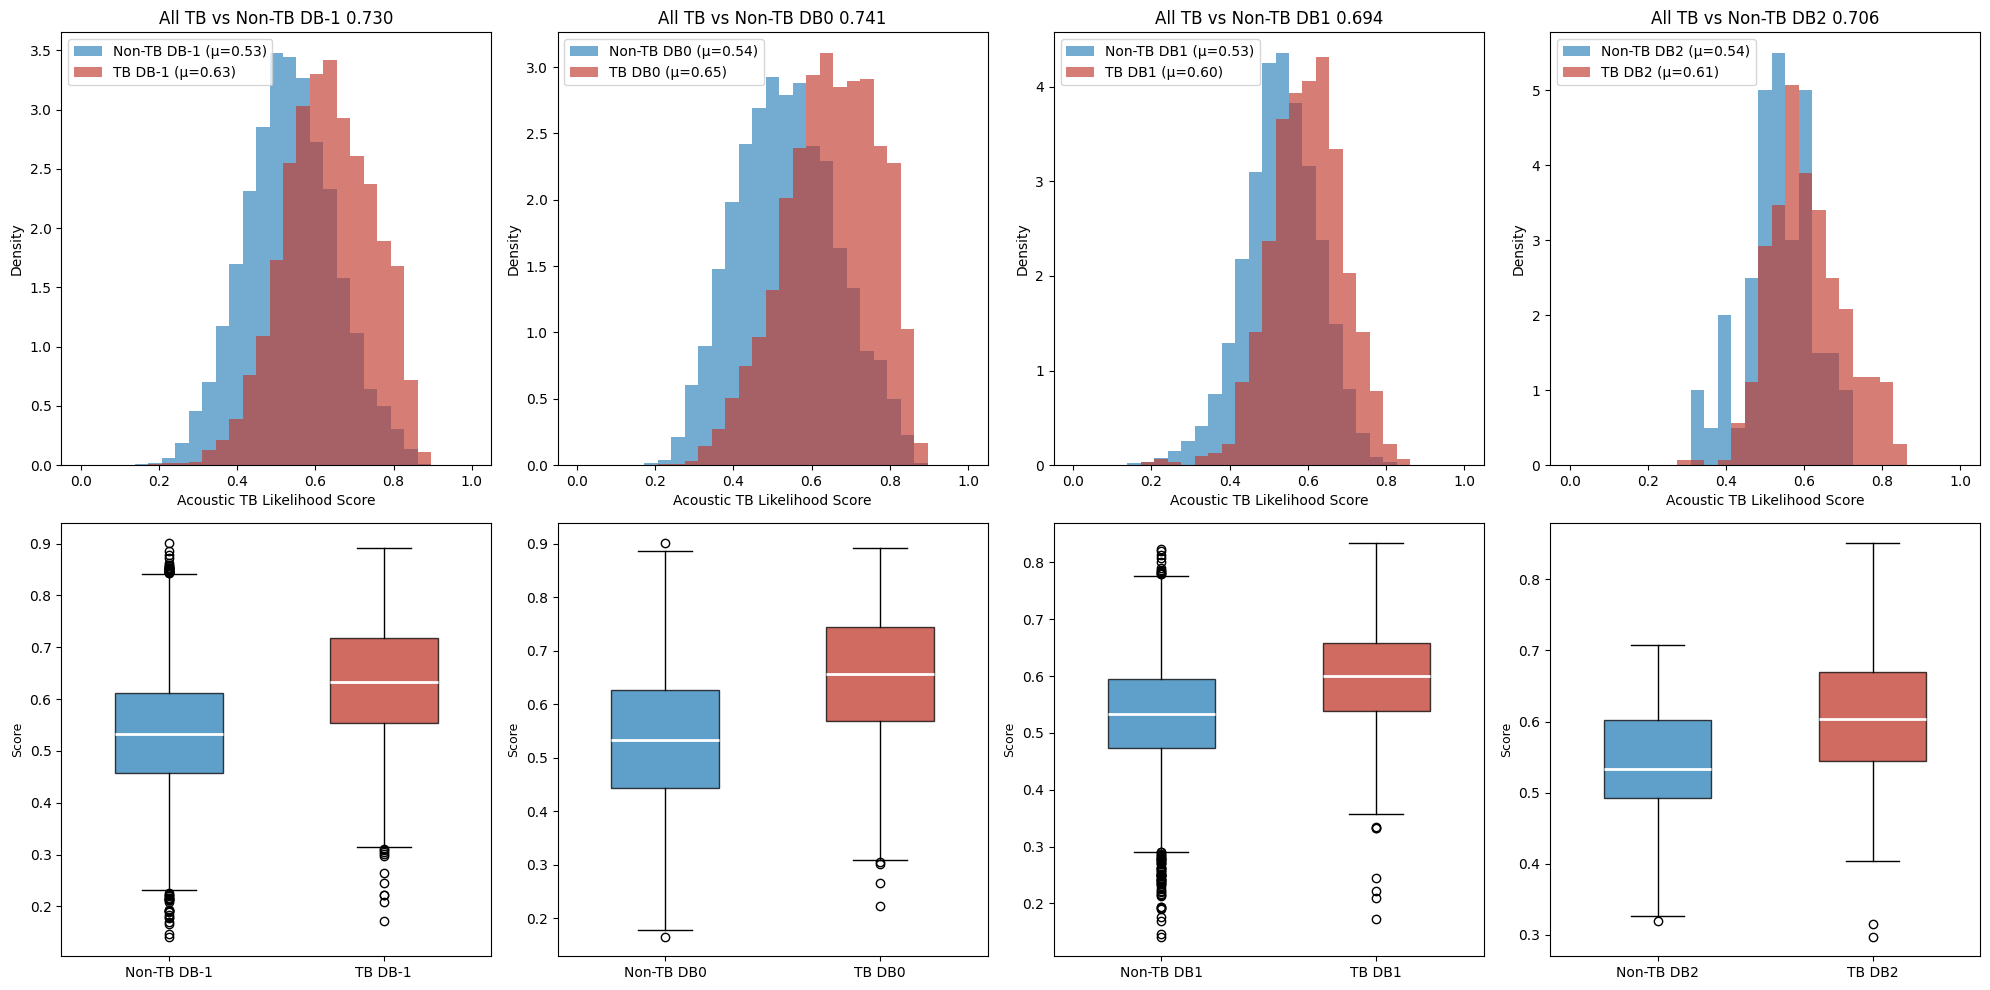

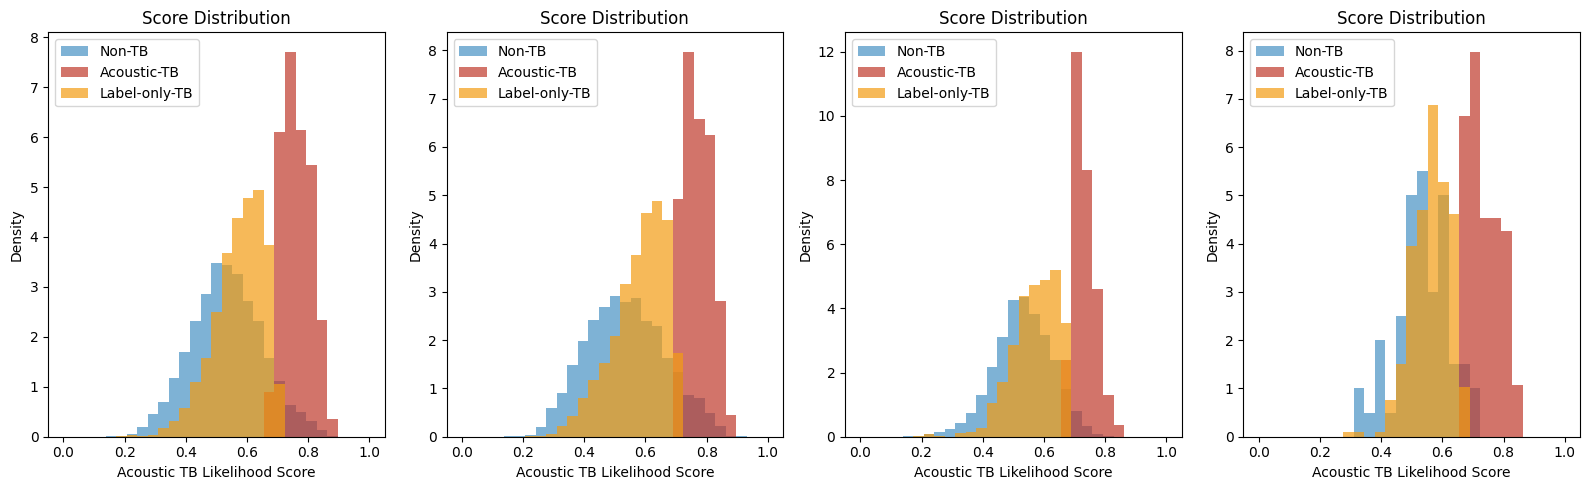

In [44]:
# Simple average — each method captures different aspects
scores_ensembles =  np.mean([all_scores["glr"], all_scores["lof_margin"]], axis=0)   #np.mean([all_scores["knn_euc"], all_scores["knn_cos"]], axis=0) # np.mean(list(all_scores.values()), axis=0) # np.mean([all_scores["knn_cos"], all_scores["gmm"]], axis=0) np.mean([all_scores["knn_euc"], all_scores["gmm"]], axis=0) #
all_scores["ensemble"] = scores_ensembles
acoustic_scores = scores_ensembles

validate_acoustic_score_indiv(emb_reduced, disease_labels, acoustic_scores)
df_temp = evaluate_acoustic_tb(df_current, acoustic_scores, global_thres=False)
plot_tb_score_distributions(df_temp, bins=bins, colors=colors)
plot_tb_split_filter(df_temp, bins)

In [ ]:
# ── Test 6: Permutation Test ───────────────────────────────
n_permutations = 500
random_state = 42

print(f"\n[4/4] Permutation Test ({n_permutations} permutations)...")
real_sep = float(acoustic_scores[tb_mask].mean() - acoustic_scores[~tb_mask].mean())

rng  = np.random.RandomState(random_state)
null = []
for i in tqdm(range(n_permutations)):
    perm_labels = rng.permutation(disease_labels)
    perm_tb     = perm_labels == 1
    # Use ensemble directly on permuted labels to avoid full recompute
    # Quick kNN proxy: re-score using same embeddings, permuted labels
    from sklearn.neighbors import NearestNeighbors as _NN
    k = min(15, perm_tb.sum(), (~perm_tb).sum())
    nn_tb_p    = _NN(n_neighbors=k, metric="euclidean", n_jobs=-1).fit(emb_reduced[perm_tb])
    nn_nontb_p = _NN(n_neighbors=k, metric="euclidean", n_jobs=-1).fit(emb_reduced[~perm_tb])
    d_tb_p,    _ = nn_tb_p.kneighbors(emb_reduced)
    d_nontb_p, _ = nn_nontb_p.kneighbors(emb_reduced)
    perm_score   = d_nontb_p.mean(1) / (d_tb_p.mean(1) + d_nontb_p.mean(1) + 1e-8)
    null.append(perm_score[perm_tb].mean() - perm_score[~perm_tb].mean())

    if (i + 1) % 200 == 0:
        print(f"    {i+1}/{n_permutations} permutations done...")

null  = np.array(null)
pval6 = float((null >= real_sep).mean())
# Two-sided: take whichever tail is more extreme
pval6 = min(pval6, 1 - pval6) * 2
pval6 = max(pval6, 1 / n_permutations)   # floor at 1/n_perms

sig6      = "***" if pval6 < 0.001 else "**" if pval6 < 0.01 else "*" if pval6 < 0.05 else "n.s."
real_sig  = pval6 < 0.05
verdict6  = (
    f"✓ REAL SIGNAL — separation={real_sep:.4f} unlikely under random labels "
    f"(p={pval6:.4f} {sig6})"
    if real_sig else
    f"✗ NOT SIGNIFICANT — separation={real_sep:.4f} could occur by chance "
    f"(p={pval6:.4f} {sig6})"
)
print(f"  Real separation (TB mean - NonTB mean): {real_sep:.4f}")
print(f"  Null mean ± std: {null.mean():.4f} ± {null.std():.4f}")
print(f"  p-value: {pval6:.4f} {sig6}")
print(f"  → {verdict6}")


### Separate TB Coughs

In [ ]:
filter_perdb = False
df_filtered = df_current.copy()
df_filtered["acoustic_tb_score"] = acoustic_scores

if filter_perdb:
    df_db0 = df_current[df_current['db'] == 0].copy().reset_index(drop=True)
    df_db1 = df_current[df_current['db'] == 1].copy().reset_index(drop=True)

    tb_mask0 = df_db0["disease_status"] == 1
    tb_mask1 = df_db1["disease_status"] == 1

    df_db0["disease_status_rev"] = 0
    threshold_0 = df_db0[tb_mask0]['acoustic_tb_score'].median()
    #threshold_0 = np.percentile(df_db0[~tb_mask0]['acoustic_tb_score'].values, 99) + 0.05
    #threshold_0 = np.percentile(df_db0[tb_mask0]['acoustic_tb_score'].values, 35) 
    df_db0.loc[tb_mask0, "disease_status_rev"] = np.where(
        df_db0.loc[tb_mask0, "acoustic_tb_score"].values >= threshold_0, 1, 2
    )

    df_db1["disease_status_rev"] = 0
    threshold_1 = df_db1[tb_mask1]['acoustic_tb_score'].median()
    df_db1.loc[tb_mask1, "disease_status_rev"] = np.where(
        df_db1.loc[tb_mask1, "acoustic_tb_score"].values >= threshold_1, 1, 2
    )

    df_rev = pd.concat([df_db0[["path_file", "disease_status_rev"]], df_db1[["path_file", "disease_status_rev"]]])
    df_current["disease_status_rev"] = (df_current["path_file"].map(df_rev.set_index("path_file")["disease_status_rev"]))
else:
    df_filtered = revised_label_df(df_filtered, acoustic_scores)

In [ ]:
df_eval = (
    df_filtered[
        (df_filtered["disease_status_rev"] != 2) #& (df_current["db"] != 2)
    ]
    .copy()
    .reset_index(drop=True)
)
summary, model_results = run_embedding_classification(
    df_eval,
    train_db=0,
    test_dbs=[1, 2],
    label_col="disease_status_rev",
)
summary

In [ ]:
summary, model_results = run_embedding_classification(
    df_eval,
    train_db=1,
    test_dbs=[0, 2],
    label_col="disease_status_rev",
)
summary

In [ ]:
df_tosave = df_filtered.copy()
df_tosave = df_tosave.drop(columns=["embed", "acoustic_tb_score", "disease_status"], errors="ignore")
df_tosave = df_tosave.rename(columns={"disease_status_rev": "disease_status"}, errors="ignore")
df_tosave['split'] = 'train'
df_tosave = df_tosave[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'split', 'db']]

In [ ]:
df_tosave[df_tosave['db'] == 0].reset_index(drop=True).to_csv("data/metadata_coda_solicited_filtered.csv.train", index=False)
df_tosave[df_tosave['db'] == 1].reset_index(drop=True).to_csv("data/metadata_cirdz_filtered.csv.train", index=False)
df_tosave[df_tosave['db'] == 2].reset_index(drop=True).to_csv("data/metadata_tbscreen_filtered.csv.train", index=False)

## Evaluate

In [ ]:
from scipy.stats import mannwhitneyu

methods = list(all_scores.keys()) #[m for m in ["kde", "knn", "gmm", "ocsvm", "lof", "ensemble"] if m in all_scores] # ["ensemble"]
n = len(methods)

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))#plt.subplots(2, n, figsize=(4 * n, 8)) plt.subplots(2, n, figsize=(14, 8))
fig.suptitle("Acoustic TB Likelihood", fontsize=14, fontweight="bold") #suptitle("Acoustic TB Likelihood — Method Comparison", fontsize=14, fontweight="bold", y=1.01)

method_labels = {"kde": "One-Class KDE\n(Non-TB density anomaly)",
                     "knn": "k-NN Distance\n(local neighborhood)",
                     "gmm": "GMM Posterior\nP(TB|x)",
                     "ensemble": "Ensemble\n(average of 3)"}
# method_labels.get(method, method)
colors = {"TB": "#C0392B", "Non-TB": "#2980B9"}

for col, method in enumerate(methods):
    scores = all_scores[method]
    tb_scores    = scores[tb_mask]
    nontb_scores = scores[~tb_mask]

    # Row 0: distribution
    ax = axes[0, col]
    bins = np.linspace(0, 1, 35)
    ax.hist(nontb_scores, bins=bins, color=colors["Non-TB"], alpha=0.65,
            label=f"Non-TB (μ={nontb_scores.mean():.2f})", density=True)
    ax.hist(tb_scores, bins=bins, color=colors["TB"], alpha=0.65,
            label=f"TB (μ={tb_scores.mean():.2f})", density=True)

    # AUC-like separation: how well does this score separate classes?
    from sklearn.metrics import roc_auc_score
    try:
        auc = roc_auc_score(tb_mask.astype(int), scores)
        auc = max(auc, 1 - auc)  # always report > 0.5
    except Exception:
        auc = float("nan")

    ax.set_title(f"{method}\nAUROC = {auc:.3f}",
                    fontsize=10, fontweight="bold")
    ax.set_xlabel("Score", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)

    # Row 1: box plot per class
    ax = axes[1, col]
    data_plot = [nontb_scores, tb_scores]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], [colors["Non-TB"], colors["TB"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Non-TB", "TB"], fontsize=10)
    ax.set_ylabel("Score", fontsize=9)

    # Statistical test
    stat, pval = mannwhitneyu(tb_scores, nontb_scores, alternative="two-sided")
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
    ymax = max(tb_scores.max(), nontb_scores.max())
    ax.annotate("", xy=(2, ymax * 1.05), xytext=(1, ymax * 1.05),
                arrowprops=dict(arrowstyle="-", color="black"))
    ax.text(1.5, ymax * 1.07, f"p={pval:.2e} {sig}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
fig.savefig(
    "docs/unsupervised_distri/figures/TB Likelihood.png",
    dpi=300,
    bbox_inches="tight"
)

results = {}
method_names = [m for m in all_scores if m != "ensemble"]
tb_score_df = pd.DataFrame(
    {m: all_scores[m][tb_mask] for m in method_names}
)
rank_corr = tb_score_df.rank().corr(method="spearman")

# Extract upper triangle (pairwise, no self-correlation)
n_methods = len(method_names)
pairs, rhos = [], []
for i in range(n_methods):
    for j in range(i + 1, n_methods):
        m1, m2 = method_names[i], method_names[j]
        rho = rank_corr.loc[m1, m2]
        pairs.append((m1, m2))
        rhos.append(rho)

mean_rho     = float(np.mean(rhos))
median_rho   = float(np.median(rhos))
pct_positive = float((np.array(rhos) > 0.4).mean() * 100)

results["rank_correlation"] = {
    "mean_rho":     mean_rho,
    "median_rho":   median_rho,
    "pct_positive": pct_positive,
    "rank_corr_matrix": rank_corr,
    "pairs": pairs,
    "rhos":  rhos,
}

consistent = mean_rho > 0.4
verdict4 = (
    f"✓ CONSISTENT — mean ρ={mean_rho:.3f}, methods agree on TB ranking"
    if consistent else
    f"✗ INCONSISTENT — mean ρ={mean_rho:.3f}, methods disagree (noise?)"
)
print(f"  Mean pairwise Spearman ρ (within TB): {mean_rho:.3f}")
print(f"  Median ρ: {median_rho:.3f}  |  Pairs with ρ>0.4: {pct_positive:.0f}%")
print(f"  → {verdict4}")

fig, axes = plt.subplots(1, 1, figsize=(18, 14))

ax2 = axes
rc  = results.get("rank_correlation", {})
mat = rc["rank_corr_matrix"]
im  = ax2.imshow(mat.values, vmin=-1, vmax=1, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax2, shrink=0.8, label="Spearman ρ")
labels = [m[:12] for m in mat.columns]
ax2.set_xticks(range(len(labels)))
ax2.set_yticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax2.set_yticklabels(labels, fontsize=7)
for i in range(len(mat)):
    for j in range(len(mat)):
        ax2.text(j, i, f"{mat.values[i,j]:.2f}",
                    ha="center", va="center", fontsize=6,
                    color="black" if abs(mat.values[i,j]) < 0.7 else "white")
ax2.set_title(
f"Test 4 — Cross-Method Rank Correlation\n"
f"Mean ρ={rc['mean_rho']:.3f}  Median ρ={rc['median_rho']:.3f}\n"
f"{'✓ Consistent' if rc['mean_rho'] > 0.4 else '✗ Inconsistent'}",
fontsize=10, fontweight="bold")

In [ ]:
COLORS = ["#C0392B", "#2980B9", "#27AE60", "#8E44AD"]

def plot_cross_dataset_roc(cross_results: dict, save_path: str = None):
    """
    ROC curves for all cross-dataset directions, one panel per direction.
    All classifiers shown per panel.
    """
    directions = list(cross_results.keys())
    n = len(directions)
    if n == 0:
        return

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle("Cross-Dataset Generalization — ROC Curves",
                 fontsize=14, fontweight="bold")

    for ax, direction in zip(axes, directions):
        clf_results = cross_results[direction]
        for (clf_name, res), color in zip(clf_results.items(), COLORS):
            ax.plot(res["fpr"], res["tpr"], color=color, linewidth=2,
                    label=f"{clf_name} (AUROC={res['auroc']:.3f})")

        ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
        ax.set_title(f"Train → Test:\n{direction}", fontsize=11, fontweight="bold")
        ax.set_xlabel("False Positive Rate", fontsize=10)
        ax.set_ylabel("True Positive Rate", fontsize=10)
        ax.legend(fontsize=8, loc="lower right")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
        _style_ax(ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.close()

In [ ]:
import pickle

file_path = "/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/logs/search_bilstm_logmel/optuna_best.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)